In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import warnings
from pathlib import Path
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# Suppress runtime warnings for divisions by zero in empty arrays
warnings.filterwarnings('ignore', category=RuntimeWarning)

# =========================================================
# 1. Metric Calculation Functions
# =========================================================
def calc_nse(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) == 0 or np.sum((obs - np.mean(obs))**2) == 0:
        return np.nan
    return 1 - (np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2))

def calc_kge(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) < 2 or np.std(obs) == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def calc_pbias(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) == 0 or np.sum(obs) == 0:
        return np.nan
    return 100 * np.sum(sim - obs) / np.sum(obs)

def calc_melt_metrics(act_df, pred_df):
    """Helper function to calculate correlation, RMSE, MPE, and MdPE for flattened datasets."""
    act = act_df.values.flatten()
    pred = pred_df.values.flatten()
    
    valid = ~(np.isnan(act) | np.isnan(pred))
    act, pred = act[valid], pred[valid]
    
    if len(act) < 2:
        return np.nan, np.nan, np.nan, np.nan, np.nan
        
    r, _ = stats.pearsonr(act, pred)
    rho, _ = stats.spearmanr(act, pred)
    rmse = np.sqrt(np.mean((pred - act)**2))
    
    # Percent Errors (Mask out actual volumes < 0.01 MCM to prevent dividing by zero)
    safe_mask = act > 0.01 
    if np.sum(safe_mask) > 0:
        pct_errors = ((pred[safe_mask] - act[safe_mask]) / act[safe_mask]) * 100
        mpe = np.mean(pct_errors)
        mdpe = np.median(pct_errors)
    else:
        mpe, mdpe = np.nan, np.nan
        
    return r, rho, rmse, mpe, mdpe

# =========================================================
# 2. Setup and Load Static / Index Data
# =========================================================
print("Loading observation data and setting up test indices...")

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) 
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)

df_test_template = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
test_dates = df_test_template.index
test_stations = df_test_template.columns
test_years = np.unique(test_dates.year)

df_obs_test = df_obs.loc[test_dates, test_stations].copy()

glac_stations = df_attr[df_attr['glacier_pct'] > 0.0].index
common_glac_stations = glac_stations.intersection(test_stations).intersection(df_mb.columns)
basin_areas = df_attr.loc[common_glac_stations, 'basin_area_km2']

print("Converting ground truth units (m^3/s -> mm/day)...")
for stat in test_stations:
    area_km2 = df_attr.loc[stat, 'basin_area_km2']
    df_obs_test[stat] = df_obs_test[stat] * (86.4 / area_km2)

# Prepare Actual Mass Balance for Aug, JJA, and Annual
df_mb_glac = df_mb[common_glac_stations]

df_act_aug = df_mb_glac[df_mb_glac.index.month == 8].groupby(df_mb_glac[df_mb_glac.index.month == 8].index.year).sum()
df_act_jja = df_mb_glac[df_mb_glac.index.month.isin([6, 7, 8])].groupby(df_mb_glac[df_mb_glac.index.month.isin([6, 7, 8])].index.year).sum()
df_act_ann = df_mb_glac.groupby(df_mb_glac.index.year).sum()

df_act_aug = df_act_aug.loc[df_act_aug.index.intersection(test_years)]
df_act_jja = df_act_jja.loc[df_act_jja.index.intersection(test_years)]
df_act_ann = df_act_ann.loc[df_act_ann.index.intersection(test_years)]

# =========================================================
# 3. Model Evaluation Loop
# =========================================================
models_to_evaluate = ["phase_split", "topographic", "area", "baseline"]

for model in models_to_evaluate:
    print(f"\n{'='*85}")
    print(f"EVALUATING MODEL: {model.upper()}")
    print(f"{'='*85}")
    
    ensemble_dir = OUTPUT_DATA_DIR / model
    prefix = model.replace("_", "-") 
    
    # Streamflow metrics tracking
    ens_mean_nse, ens_med_nse, ens_max_nse, ens_min_nse, ens_nse_below_0 = [], [], [], [], []
    ens_mean_kge, ens_med_kge, ens_max_kge, ens_min_kge, ens_kge_below_0 = [], [], [], [], []
    ens_mean_kge_aug, ens_med_kge_aug = [], []
    ens_mean_kge_glac, ens_med_kge_glac = [], []
    ens_mean_pbias, ens_med_pbias = [], []
    ens_mean_pbias_aug, ens_med_pbias_aug = [], []
    
    # Glacier metrics tracking
    ens_pct_neg_preds, ens_pct_neg_basins = [], []
    
    # Aug, JJA, Ann metrics (r, rho, rmse, mpe, mdpe)
    ens_aug_metrics = {'r': [], 'rho': [], 'rmse': [], 'mpe': [], 'mdpe': []}
    ens_jja_metrics = {'r': [], 'rho': [], 'rmse': [], 'mpe': [], 'mdpe': []}
    ens_ann_metrics = {'r': [], 'rho': [], 'rmse': [], 'mpe': [], 'mdpe': []}

    for i in range(10):
        # -------------------------------------------------
        # A. Streamflow Performance 
        # -------------------------------------------------
        file_path = ensemble_dir / f"{prefix}_preds_member_{i}.csv"
        df_pred = pd.read_csv(file_path, index_col=0, parse_dates=True)
        df_pred_test = df_pred.loc[test_dates, test_stations]
        
        mem_nse_all, mem_kge_all, mem_pbias_all = [], [], []
        mem_kge_aug, mem_pbias_aug, mem_kge_glac = [], [], []
        
        for stat in test_stations:
            obs, sim = df_obs_test[stat].values, df_pred_test[stat].values
            aug_mask = test_dates.month == 8
            obs_aug, sim_aug = obs[aug_mask], sim[aug_mask]
            
            nse, kge, pbias = calc_nse(obs, sim), calc_kge(obs, sim), calc_pbias(obs, sim)
            kge_aug, pbias_aug = calc_kge(obs_aug, sim_aug), calc_pbias(obs_aug, sim_aug)
            
            mem_nse_all.append(nse)
            mem_kge_all.append(kge)
            mem_pbias_all.append(pbias)
            mem_kge_aug.append(kge_aug)
            mem_pbias_aug.append(pbias_aug)
            if stat in glac_stations: mem_kge_glac.append(kge)
                
        ens_mean_nse.append(np.nanmean(mem_nse_all))
        ens_med_nse.append(np.nanmedian(mem_nse_all))
        ens_max_nse.append(np.nanmax(mem_nse_all))
        ens_min_nse.append(np.nanmin(mem_nse_all))
        ens_nse_below_0.append(np.sum(np.array(mem_nse_all) < 0))
        
        ens_mean_kge.append(np.nanmean(mem_kge_all))
        ens_med_kge.append(np.nanmedian(mem_kge_all))
        ens_max_kge.append(np.nanmax(mem_kge_all))
        ens_min_kge.append(np.nanmin(mem_kge_all))
        ens_kge_below_0.append(np.sum(np.array(mem_kge_all) < 0))
        
        ens_mean_kge_aug.append(np.nanmean(mem_kge_aug))
        ens_med_kge_aug.append(np.nanmedian(mem_kge_aug))
        ens_mean_kge_glac.append(np.nanmean(mem_kge_glac))
        ens_med_kge_glac.append(np.nanmedian(mem_kge_glac))
        
        ens_mean_pbias.append(np.nanmean(mem_pbias_all))
        ens_med_pbias.append(np.nanmedian(mem_pbias_all))
        ens_mean_pbias_aug.append(np.nanmean(mem_pbias_aug))
        ens_med_pbias_aug.append(np.nanmedian(mem_pbias_aug))

        # -------------------------------------------------
        # B. Glacier Melt Extraction Performance
        # -------------------------------------------------
        noglac_path = ensemble_dir / f"{prefix}_preds_noglacier_member_{i}.csv"
        df_noglac = pd.read_csv(noglac_path, index_col=0, parse_dates=True)
        
        diff_mm = df_pred.loc[test_dates, common_glac_stations] - df_noglac.loc[test_dates, common_glac_stations]
        
        # Calculate sums for Aug, JJA, and Annual
        diff_aug = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
        diff_jja = diff_mm[diff_mm.index.month.isin([6, 7, 8])].groupby(diff_mm[diff_mm.index.month.isin([6, 7, 8])].index.year).sum()
        diff_ann = diff_mm.groupby(diff_mm.index.year).sum()
        
        pred_mcm_aug = (diff_aug * basin_areas * 0.001).loc[df_act_aug.index]
        pred_mcm_jja = (diff_jja * basin_areas * 0.001).loc[df_act_jja.index]
        pred_mcm_ann = (diff_ann * basin_areas * 0.001).loc[df_act_ann.index]
        
        # Calculate Negative Melt Percentages
        neg_preds = (pred_mcm_ann < 0).sum().sum()
        total_preds = pred_mcm_ann.notna().sum().sum()
        ens_pct_neg_preds.append((neg_preds / total_preds) * 100 if total_preds > 0 else 0)
        
        neg_basins = (pred_mcm_ann < 0).any(axis=0).sum()
        total_basins = pred_mcm_ann.shape[1]
        ens_pct_neg_basins.append((neg_basins / total_basins) * 100 if total_basins > 0 else 0)
        
        # Calculate Metrics for each time period
        for act, pred, metric_dict in zip(
            [df_act_aug, df_act_jja, df_act_ann], 
            [pred_mcm_aug, pred_mcm_jja, pred_mcm_ann], 
            [ens_aug_metrics, ens_jja_metrics, ens_ann_metrics]
        ):
            r, rho, rmse, mpe, mdpe = calc_melt_metrics(act, pred)
            metric_dict['r'].append(r)
            metric_dict['rho'].append(rho)
            metric_dict['rmse'].append(rmse)
            metric_dict['mpe'].append(mpe)
            metric_dict['mdpe'].append(mdpe)

    # -------------------------------------------------
    # C. Print Metrics for Current Model
    # -------------------------------------------------
    def print_stat(name, mean_list, med_list=None, unit=""):
        if med_list is not None:
            print(f"{name:<42}: Mean = {np.mean(mean_list):7.3f}{unit} ± {np.std(mean_list):.3f}  |  Median = {np.mean(med_list):7.3f}{unit} ± {np.std(med_list):.3f}")
        else:
            print(f"{name:<42}: {np.mean(mean_list):7.3f}{unit} ± {np.std(mean_list):.3f}")

    print("\n--- STREAMFLOW PERFORMANCE (KGE/NSE) ---")
    print_stat("Overall NSE (All Stations)", ens_mean_nse, ens_med_nse)
    print_stat("Overall KGE (All Stations)", ens_mean_kge, ens_med_kge)
    print_stat("August KGE (All Stations)", ens_mean_kge_aug, ens_med_kge_aug)
    print_stat("Overall KGE (Glaciated Only)", ens_mean_kge_glac, ens_med_kge_glac)
    
    print("\n--- STREAMFLOW BIAS & EXTREMES ---")
    print_stat("Percent Bias (All Stations)", ens_mean_pbias, ens_med_pbias, unit="%")
    print_stat("August Percent Bias (All Stations)", ens_mean_pbias_aug, ens_med_pbias_aug, unit="%")
    print(f"{'Max / Min NSE Achieved':<42}: Max = {np.mean(ens_max_nse):7.3f}  |  Min = {np.mean(ens_min_nse):7.3f}")
    print(f"{'Max / Min KGE Achieved':<42}: Max = {np.mean(ens_max_kge):7.3f}  |  Min = {np.mean(ens_min_kge):7.3f}")
    print(f"{'Stations with NSE < 0 (Count)':<42}: {np.mean(ens_nse_below_0):7.1f} ± {np.std(ens_nse_below_0):.1f}")
    print(f"{'Stations with KGE < 0 (Count)':<42}: {np.mean(ens_kge_below_0):7.1f} ± {np.std(ens_kge_below_0):.1f}")
    
    print("\n--- GLACIER MELT ISOLATION (AUGUST) ---")
    print_stat("Pearson r (Linear Volume)", ens_aug_metrics['r'])
    print_stat("Spearman ρ (Rank Agreement)", ens_aug_metrics['rho'])
    print_stat("RMSE (Volume Error)", ens_aug_metrics['rmse'], unit=" MCM")
    print_stat("Percent Error", ens_aug_metrics['mpe'], ens_aug_metrics['mdpe'], unit="%")

    print("\n--- GLACIER MELT ISOLATION (SUMMER: JJA) ---")
    print_stat("Pearson r (Linear Volume)", ens_jja_metrics['r'])
    print_stat("Spearman ρ (Rank Agreement)", ens_jja_metrics['rho'])
    print_stat("RMSE (Volume Error)", ens_jja_metrics['rmse'], unit=" MCM")
    print_stat("Percent Error", ens_jja_metrics['mpe'], ens_jja_metrics['mdpe'], unit="%")
    
    print("\n--- GLACIER MELT ISOLATION (ANNUAL) ---")
    print_stat("Pearson r (Linear Volume)", ens_ann_metrics['r'])
    print_stat("Spearman ρ (Rank Agreement)", ens_ann_metrics['rho'])
    print_stat("RMSE (Volume Error)", ens_ann_metrics['rmse'], unit=" MCM")
    print_stat("Percent Error", ens_ann_metrics['mpe'], ens_ann_metrics['mdpe'], unit="%")
    print(f"{'% of Predictions with Negative Melt':<42}: {np.mean(ens_pct_neg_preds):7.2f}% ± {np.std(ens_pct_neg_preds):.2f}%")
    print(f"{'% of Basins with a Negative Prediction':<42}: {np.mean(ens_pct_neg_basins):7.2f}% ± {np.std(ens_pct_neg_basins):.2f}%")
    print("-" * 85)

print("\nDone evaluating all models!")

Loading observation data and setting up test indices...
Converting ground truth units (m^3/s -> mm/day)...

EVALUATING MODEL: PHASE_SPLIT

--- STREAMFLOW PERFORMANCE (KGE/NSE) ---
Overall NSE (All Stations)                : Mean =   0.586 ± 0.054  |  Median =   0.707 ± 0.015
Overall KGE (All Stations)                : Mean =   0.611 ± 0.022  |  Median =   0.692 ± 0.032
August KGE (All Stations)                 : Mean = -28.780 ± 14.262  |  Median =   0.468 ± 0.022
Overall KGE (Glaciated Only)              : Mean =   0.833 ± 0.016  |  Median =   0.873 ± 0.019

--- STREAMFLOW BIAS & EXTREMES ---
Percent Bias (All Stations)               : Mean =  -3.058% ± 3.209  |  Median =  -3.487% ± 1.748
August Percent Bias (All Stations)        : Mean = 2885.693% ± 1443.062  |  Median =   8.476% ± 2.727
Max / Min NSE Achieved                    : Max =   0.961  |  Min =  -7.670
Max / Min KGE Achieved                    : Max =   0.969  |  Min =  -1.997
Stations with NSE < 0 (Count)             :    

Loading data and imputing...
Calculating median KGE across 10 ensemble members...
Computing hydrographs and clustering...
Generating Voronoi spatial grid...
Rendering final plot...


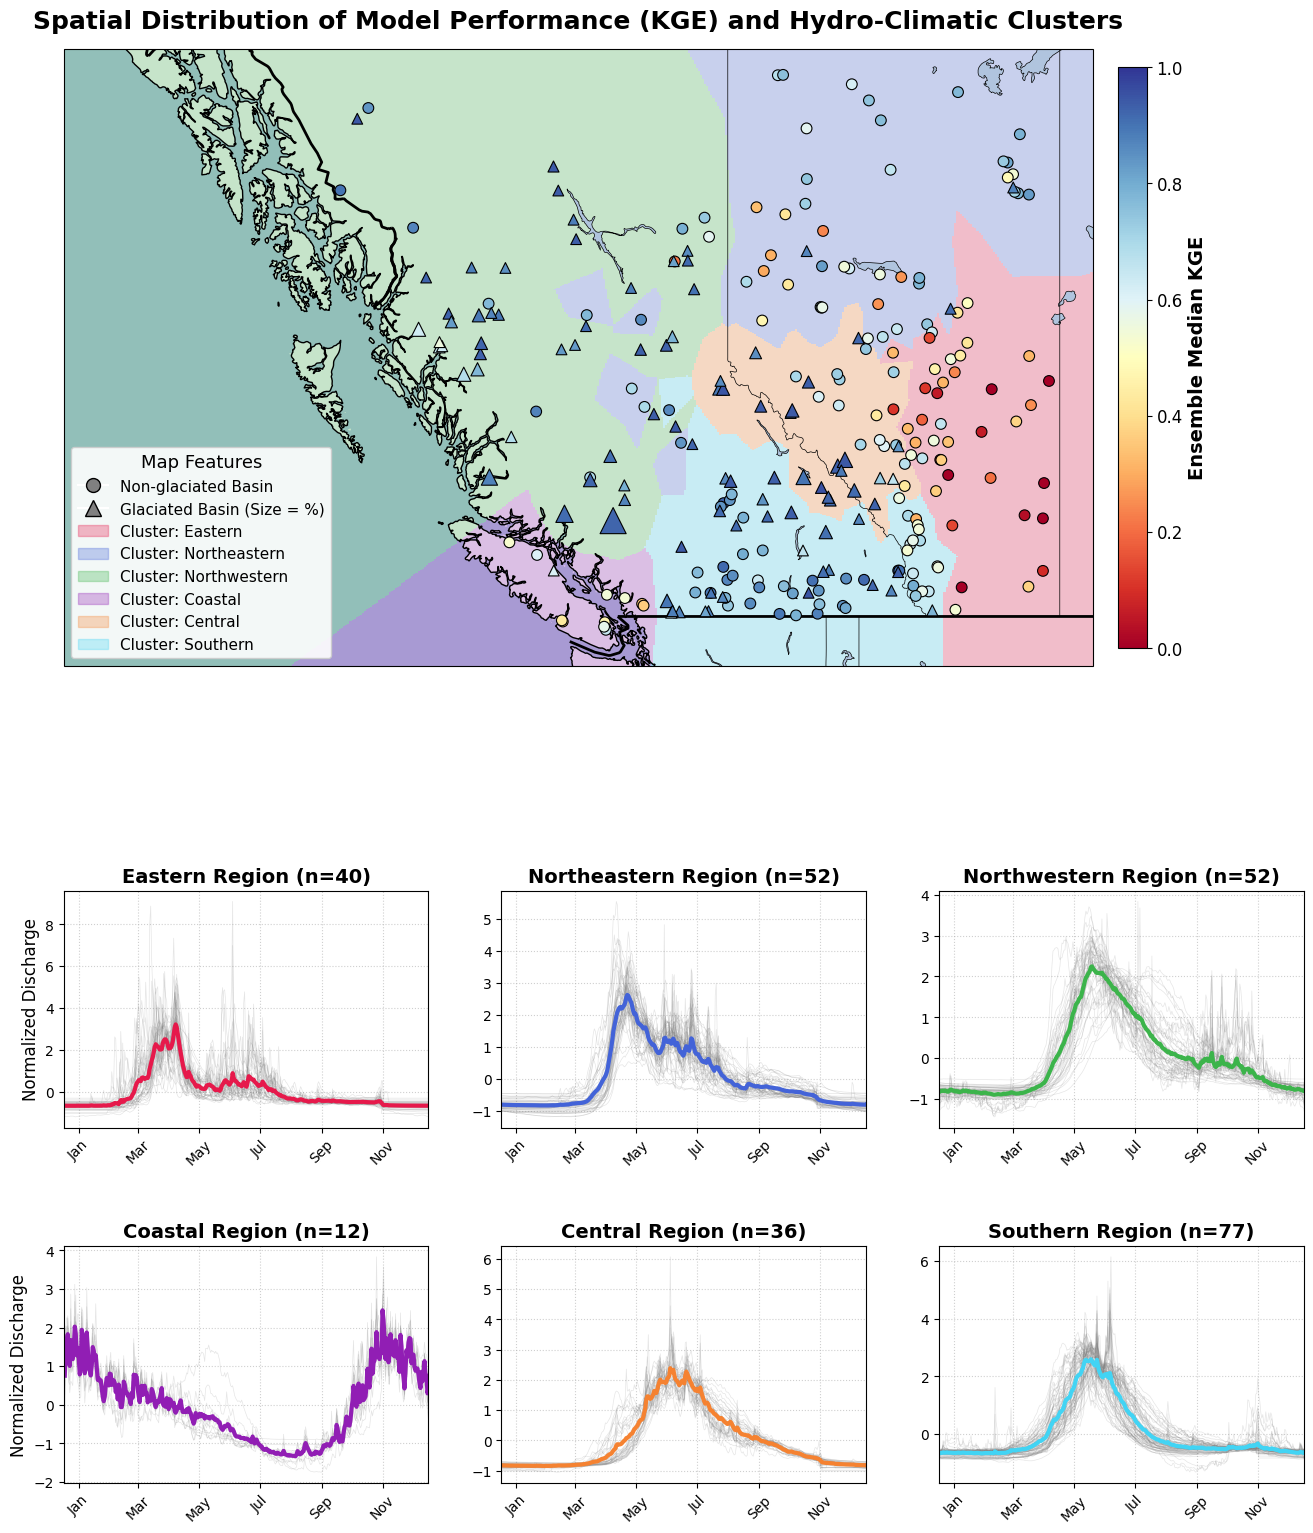

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap, Normalize
import matplotlib.cm as cm
import warnings
from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Metric Calculation Function
# =========================================================
def calc_kge(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) < 2 or np.std(obs) == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# =========================================================
# 2. Load Data & Impute
# =========================================================
print("Loading data and imputing...")
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0) 
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) 

# Convert streamflow to mm/day for KGE calculation
for stat in df_obs.columns:
    if stat in df_attr.index:
        area_km2 = df_attr.loc[stat, 'basin_area_km2']
        df_obs[stat] = df_obs[stat] * (86.4 / area_km2)

# Imputation for Hydrographs
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.year).transform('min'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())

# =========================================================
# 3. Calculate KGE across Ensemble
# =========================================================
print("Calculating median KGE across 10 ensemble members...")
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
all_stations = df_obs.columns
station_kge_lists = {stat: [] for stat in all_stations}

# Read all members and calculate KGE for the available timeseries
for i in range(10):
    df_pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)
    # Align dates
    common_dates = df_obs.index.intersection(df_pred.index)
    
    for stat in all_stations:
        if stat in df_pred.columns:
            obs_vals = df_obs.loc[common_dates, stat].values
            sim_vals = df_pred.loc[common_dates, stat].values
            station_kge_lists[stat].append(calc_kge(obs_vals, sim_vals))

# Get the median KGE per station, clipped between 0 and 1
station_median_kge = {}
for stat, kge_list in station_kge_lists.items():
    med_kge = np.nanmedian(kge_list)
    station_median_kge[stat] = np.clip(med_kge, 0, 1)

df_kge = pd.DataFrame.from_dict(station_median_kge, orient='index', columns=['KGE'])

# =========================================================
# 4. Clustering
# =========================================================
print("Computing hydrographs and clustering...")
avg_hydrograph = df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).mean()
avg_hydrograph_norm = (avg_hydrograph - avg_hydrograph.mean()) / avg_hydrograph.std()

X_hydro = avg_hydrograph_norm.T
X_merged = X_hydro.join(df_meta[['Latitude', 'Longitude']], how='inner')

hydro_features = X_merged.drop(columns=['Latitude', 'Longitude']).values
lat_norm = (X_merged['Latitude'] - X_merged['Latitude'].mean()) / X_merged['Latitude'].std()
lon_norm = (X_merged['Longitude'] - X_merged['Longitude'].mean()) / X_merged['Longitude'].std()

lat_features = np.tile(lat_norm.values, (182, 1)).T
lon_features = np.tile(lon_norm.values, (182, 1)).T

X_cluster_input = np.hstack((hydro_features, lat_features, lon_features))
Z = linkage(X_cluster_input, method='ward')

cluster_labels = fcluster(Z, t=6, criterion='maxclust') - 1

df_plot = pd.DataFrame({'Cluster': cluster_labels}, index=X_merged.index)
df_plot = df_plot.join(df_meta[['Latitude', 'Longitude']], how='inner')
df_plot = df_plot.join(df_attr[['glacier_pct']], how='left')
df_plot = df_plot.join(df_kge, how='inner')
df_plot['glacier_pct'] = df_plot['glacier_pct'].fillna(0)

cluster_names = {0: "Eastern", 1: "Northeastern", 2: "Northwestern", 3: "Coastal", 4: "Central", 5: "Southern"}
# Colors for the 6 clusters (Voronoi background)
cluster_colors = ['#e6194B', '#4363d8', '#3cb44b', '#911eb4', '#f58231', '#42d4f4']
cmap_clusters = ListedColormap(cluster_colors)

# =========================================================
# 5. Generate Voronoi Grid (KNN Approach)
# =========================================================
print("Generating Voronoi spatial grid...")
# Train KNN on station coordinates and cluster labels
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(df_plot[['Longitude', 'Latitude']], df_plot['Cluster'])

# Create a dense grid over the map area
xx, yy = np.meshgrid(np.linspace(-140, -109, 500), np.linspace(48, 59, 500))
# Predict the cluster for every point in the grid
Z_grid = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_grid = Z_grid.reshape(xx.shape)

# =========================================================
# 6. Plotting - Master Layout
# =========================================================
print("Rendering final plot...")
fig = plt.figure(figsize=(16, 20))
# Create a grid: Top half for the map, bottom half for the 6 hydrographs
gs = fig.add_gridspec(4, 3, height_ratios=[1.5, 1.5, 1, 1], hspace=0.4)

# --- PANEL A: The Map ---
ax_map = fig.add_subplot(gs[0:2, :], projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightsteelblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=2)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightsteelblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale=res, facecolor='none')
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

# Plot the Voronoi Background (Alpha is low so it acts as shading)
ax_map.pcolormesh(xx, yy, Z_grid, cmap=cmap_clusters, alpha=0.25, transform=ccrs.PlateCarree(), zorder=1)

# Plot the KGE Heatmap Points
# Using 'RdYlBu' where Red = 0 (Bad), Blue = 1 (Good)
sc_non_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] == 0]['Longitude'], 
    df_plot[df_plot['glacier_pct'] == 0]['Latitude'],
    c=df_plot[df_plot['glacier_pct'] == 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=60, marker='o', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=5
)

sc_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] > 0]['Longitude'], 
    df_plot[df_plot['glacier_pct'] > 0]['Latitude'],
    c=df_plot[df_plot['glacier_pct'] > 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=(df_plot[df_plot['glacier_pct'] > 0]['glacier_pct'] * 5) + 60, 
    marker='^', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=6
)

# Add Colorbar for KGE
cbar = plt.colorbar(sc_non_glac, ax=ax_map, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Ensemble Median KGE', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Build Custom Legend
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Non-glaciated Basin'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=12, markeredgecolor='k', label='Glaciated Basin (Size = %)')
]
# Add cluster colors to legend
for i in range(6):
    legend_elements.append(mpatches.Patch(color=cluster_colors[i], alpha=0.3, label=f'Cluster: {cluster_names[i]}'))

ax_map.legend(handles=legend_elements, loc='lower left', title="Map Features", fontsize=11, title_fontsize=13, framealpha=0.9)
ax_map.set_title('Spatial Distribution of Model Performance (KGE) and Hydro-Climatic Clusters', fontsize=18, fontweight='bold', pad=15)

# --- PANEL B: The Hydrographs ---
month_ticks = [15, 74, 135, 196, 258, 319]
month_labels = ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov']

for cluster_id in range(6):
    # Calculate grid position for hydrographs (Rows 2 and 3 of the gridspec)
    row = 2 + (cluster_id // 3)
    col = cluster_id % 3
    ax = fig.add_subplot(gs[row, col])
    
    station_names = df_plot[df_plot['Cluster'] == cluster_id].index
    cluster_hydro_data = avg_hydrograph_norm[station_names]
    
    # Plot individual faint lines
    ax.plot(cluster_hydro_data.index, cluster_hydro_data.values, color='gray', alpha=0.2, linewidth=0.5)
    
    # Plot thick mean line
    cluster_mean = cluster_hydro_data.mean(axis=1)
    ax.plot(cluster_mean.index, cluster_mean.values, color=cluster_colors[cluster_id], linewidth=3)
    
    ax.set_title(f"{cluster_names[cluster_id]} Region (n={len(station_names)})", fontsize=14, fontweight='bold')
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, rotation=45)
    ax.set_xlim(0, 365)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if col == 0:
        ax.set_ylabel('Normalized Discharge', fontsize=12)

plt.show()

Calculating ensemble statistics...


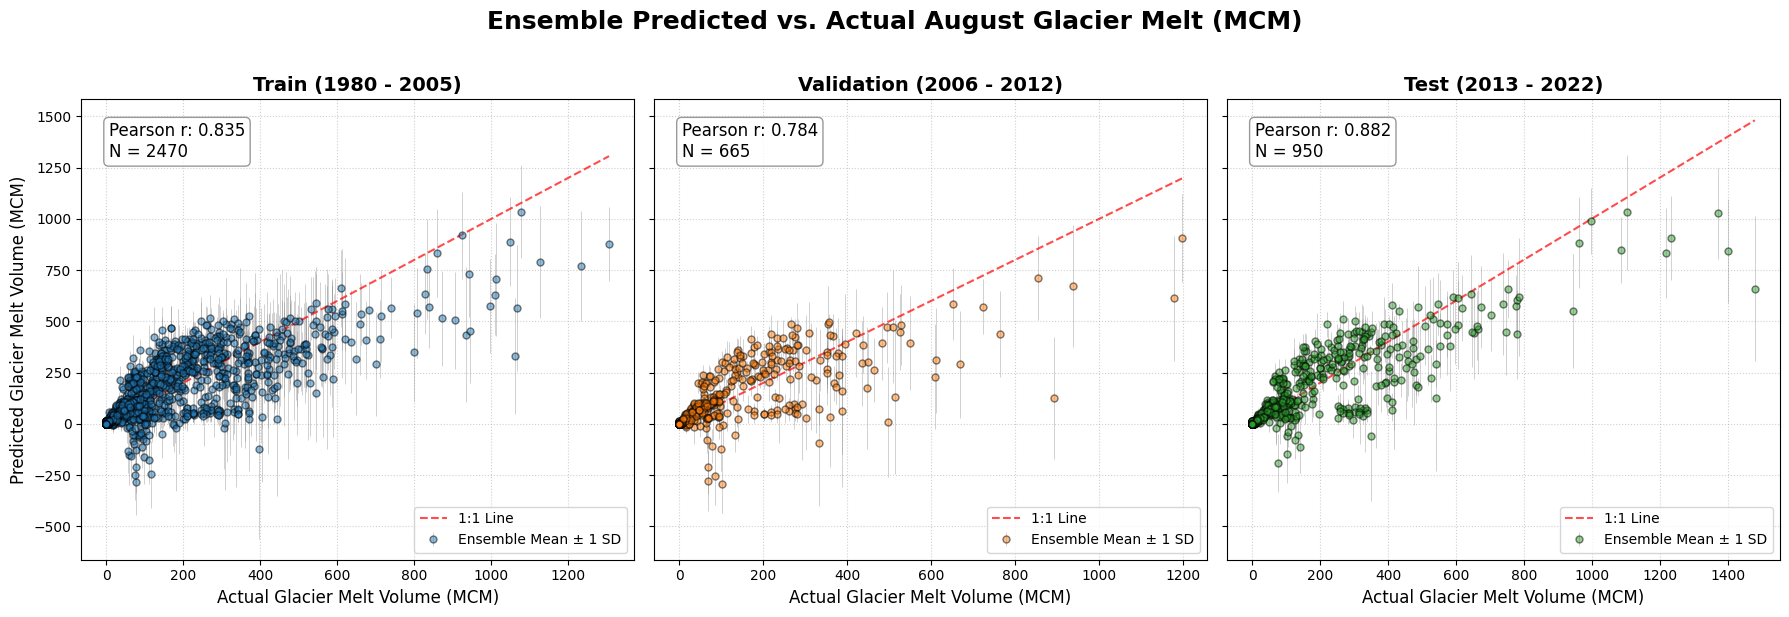

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

# =========================================================
# 1. Setup Data Paths & Lists
# =========================================================
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
num_members = 10

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index

df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)
common_stations = glaciated_stations.intersection(df_mb.columns)
df_mb = df_mb[common_stations]
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# =========================================================
# 2. Calculate Ensemble Mean & Std
# =========================================================
print("Calculating ensemble statistics...")
list_diff_mcm = []

for i in range(num_members):
    df_pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    df_pred_no_glac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    
    df_diff_mm = df_pred - df_pred_no_glac
    df_diff_aug_mm = df_diff_mm[df_diff_mm.index.month == 8].groupby(df_diff_mm[df_diff_mm.index.month == 8].index.year).sum()
    df_diff_aug_mcm = df_diff_aug_mm * basin_areas * 0.001
    list_diff_mcm.append(df_diff_aug_mcm)

# Stack to 3D array (Member, Year, Station) to compute stats across axis 0
stacked_diffs = np.stack([df.values for df in list_diff_mcm], axis=0)
mean_vals = np.mean(stacked_diffs, axis=0)
std_vals = np.std(stacked_diffs, axis=0)

# Reconstruct into DataFrames
df_pred_mcm_mean = pd.DataFrame(mean_vals, index=list_diff_mcm[0].index, columns=list_diff_mcm[0].columns)
df_pred_mcm_std = pd.DataFrame(std_vals, index=list_diff_mcm[0].index, columns=list_diff_mcm[0].columns)

df_mb_aug_yearly = df_mb[df_mb.index.month == 8].groupby(df_mb[df_mb.index.month == 8].index.year).sum()
common_years = df_mb_aug_yearly.index.intersection(df_pred_mcm_mean.index)

df_actual_mcm = df_mb_aug_yearly.loc[common_years]
df_pred_mcm = df_pred_mcm_mean.loc[common_years]
df_std_mcm = df_pred_mcm_std.loc[common_years]

# =========================================================
# 3. Updated Prep Plotting Function
# =========================================================
def get_clean_flat_data(df_actual, df_pred, df_std, start_yr, end_yr):
    mask = (df_actual.index >= start_yr) & (df_actual.index <= end_yr)
    
    act_slice = df_actual[mask].values.flatten()
    pred_slice = df_pred[mask].values.flatten()
    std_slice = df_std[mask].values.flatten()
    
    valid_mask = ~(np.isnan(act_slice) | np.isnan(pred_slice))
    x_clean = act_slice[valid_mask]
    y_clean = pred_slice[valid_mask]
    yerr_clean = std_slice[valid_mask]
    
    corr, _ = stats.pearsonr(x_clean, y_clean)
    return x_clean, y_clean, yerr_clean, corr

# =========================================================
# 4. Plotting with Error Bars
# =========================================================
periods = {
    'Train (1980 - 2005)': (1980, 2005),
    'Validation (2006 - 2012)': (2006, 2012),
    'Test (2013 - 2022)': (2013, 2022)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, (period_name, (start_yr, end_yr)) in enumerate(periods.items()):
    ax = axes[i]
    x, y, yerr, corr = get_clean_flat_data(df_actual_mcm, df_pred_mcm, df_std_mcm, start_yr, end_yr)
    
    # Using errorbar instead of scatter
    ax.errorbar(x, y, yerr=yerr, fmt='o', color=colors[i], 
                ecolor='gray', elinewidth=0.5, capsize=0, 
                alpha=0.5, markeredgecolor='k', ms=5, label='Ensemble Mean ± 1 SD')
    
    ax.set_title(f'{period_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual Glacier Melt Volume (MCM)', fontsize=12)
    if i == 0:
        ax.set_ylabel('Predicted Glacier Melt Volume (MCM)', fontsize=12)
        
    ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}\nN = {len(x)}', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', bbox=props)
            
    # 1:1 Line
    limit = max(x.max(), y.max()) if len(x) > 0 else 10
    ax.plot([0, limit], [0, limit], 'r--', alpha=0.7, label='1:1 Line')
    
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=10)

plt.suptitle('Ensemble Predicted vs. Actual August Glacier Melt (MCM)', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

Loading data...
Applying 5-day rolling smoothing...
Extracting 31-day August samples...
Retained 11067 / 11567 complete and active August station-year records.
Applying row-wise standardization (mean=0, std=1)...
Computing PCA...


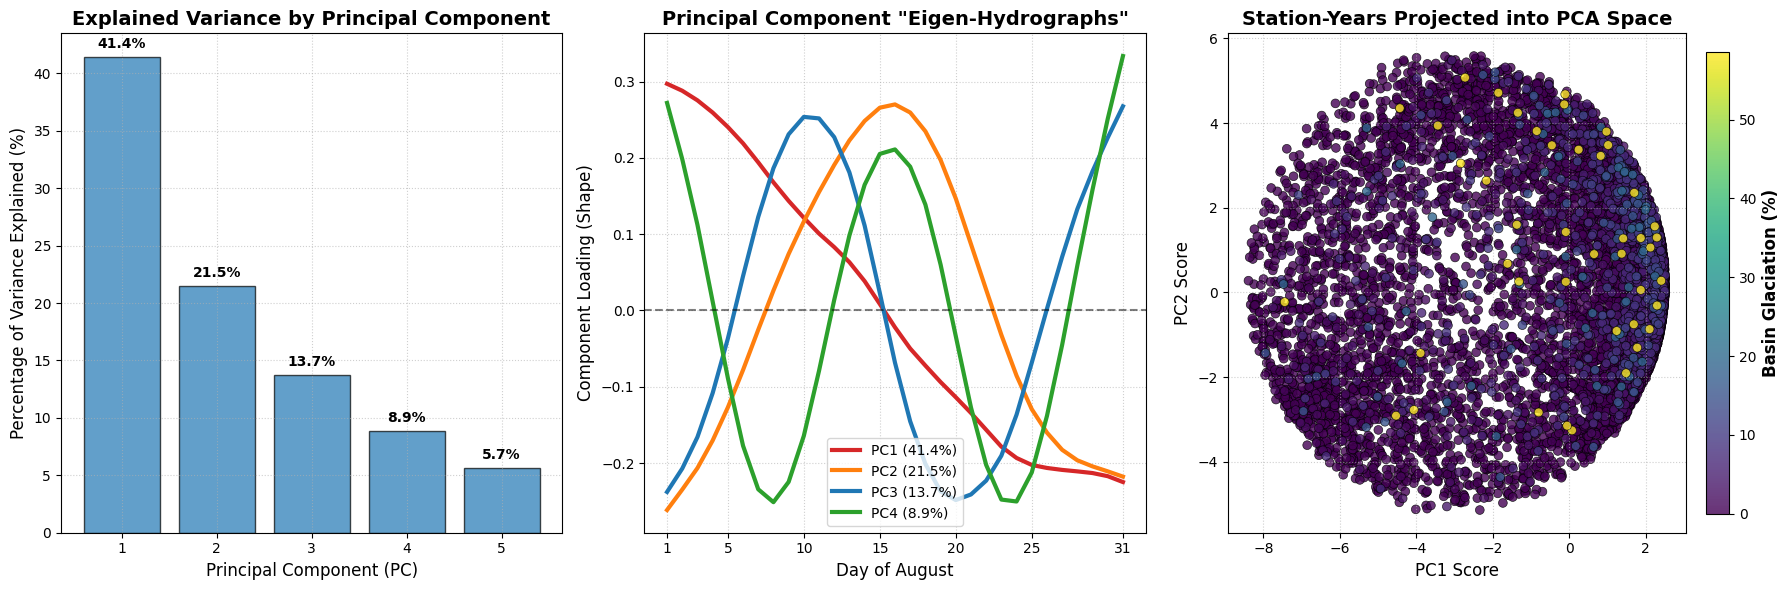

Aggregating station-years to climatological means...


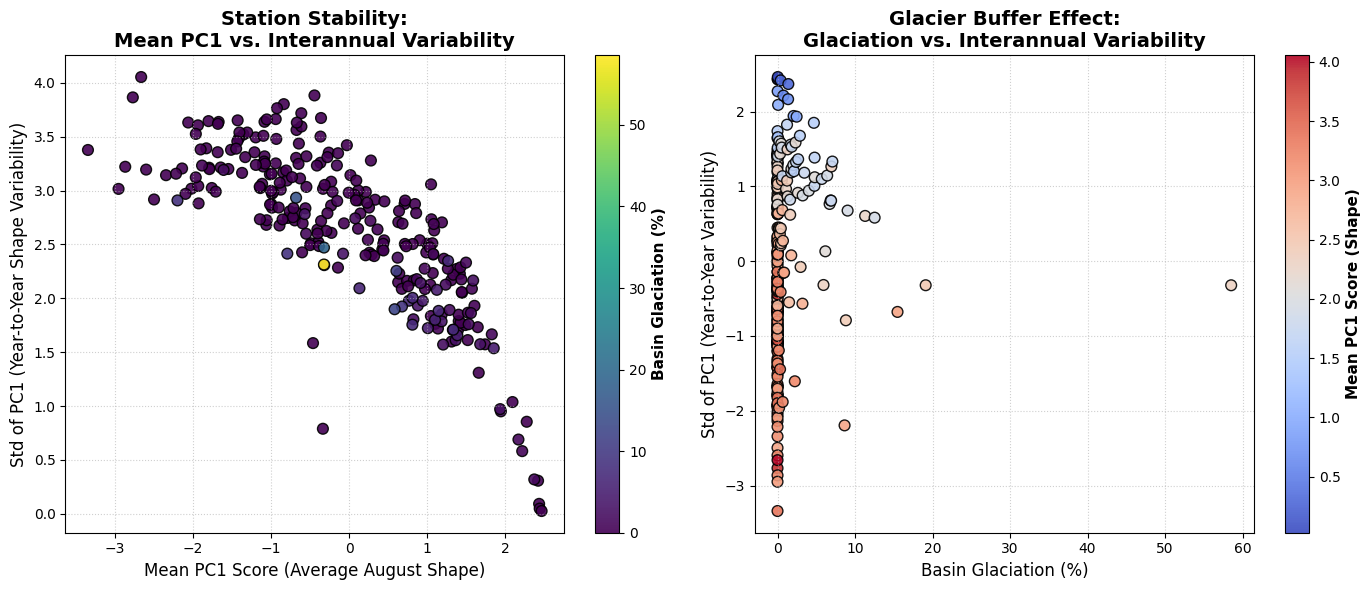

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
from src.config import PROCESSED_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Data
# =========================================================
print("Loading data...")
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)

# =========================================================
# 2. Continuous Smoothing (Anderson 2020 Methodology)
# =========================================================
print("Applying 5-day rolling smoothing...")
df_smoothed = df_obs.rolling(window=5, center=True).mean()

# =========================================================
# 3. Extract and Reshape August Data
# =========================================================
print("Extracting 31-day August samples...")

df_aug = df_smoothed[df_smoothed.index.month == 8].copy()
df_aug['Year'] = df_aug.index.year
df_aug['Day'] = df_aug.index.day

df_long = df_aug.reset_index(drop=True).melt(id_vars=['Year', 'Day'], var_name='Station', value_name='Flow')
df_long['Station_Year'] = df_long['Station'] + '_' + df_long['Year'].astype(str)

df_pivot = df_long.pivot(index='Station_Year', columns='Day', values='Flow')

# Drop any Station-Years that have missing data in August
initial_count = len(df_pivot)
df_pivot = df_pivot.dropna()

# --- THE FIX: Filter out flatline hydrographs ---
# A standard deviation of 0 will cause a divide-by-zero NaN during normalization.
# A flat line has no "shape" for PCA to extract anyway!
valid_rows = df_pivot.std(axis=1) > 0
df_pivot = df_pivot[valid_rows]

print(f"Retained {len(df_pivot)} / {initial_count} complete and active August station-year records.")

# =========================================================
# 4. Row-Wise Normalization (Shape Extraction)
# =========================================================
print("Applying row-wise standardization (mean=0, std=1)...")
df_pivot_norm = df_pivot.sub(df_pivot.mean(axis=1), axis=0).div(df_pivot.std(axis=1), axis=0)

# Final safety net to guarantee no NaNs slip into the PCA
df_pivot_norm = df_pivot_norm.dropna()

# =========================================================
# 5. Compute PCA
# =========================================================
print("Computing PCA...")
pca = PCA(n_components=5)
X_pca = pca.fit_transform(df_pivot_norm)

# =========================================================
# 6. Map Attributes for Plotting
# =========================================================
stations = [idx.split('_')[0] for idx in df_pivot_norm.index]

glac_pct = []
for s in stations:
    if s in df_attr.index and not np.isnan(df_attr.loc[s, 'glacier_pct']):
        glac_pct.append(df_attr.loc[s, 'glacier_pct'])
    else:
        glac_pct.append(0.0)

# =========================================================
# 7. Plotting
# =========================================================
fig = plt.figure(figsize=(18, 6))

# --- PANEL 1: Scree Plot (Explained Variance) ---
ax1 = plt.subplot(1, 3, 1)
bars = ax1.bar(range(1, 6), pca.explained_variance_ratio_ * 100, color='tab:blue', alpha=0.7, edgecolor='k')
ax1.set_title('Explained Variance by Principal Component', fontsize=14, fontweight='bold')
ax1.set_xlabel('Principal Component (PC)', fontsize=12)
ax1.set_ylabel('Percentage of Variance Explained (%)', fontsize=12)
ax1.set_xticks(range(1, 6))
ax1.grid(True, linestyle=':', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

# --- PANEL 2: Eigen-Hydrographs (The Shapes of PC1 and PC2) ---
ax2 = plt.subplot(1, 3, 2)
days = np.arange(1, 32)
ax2.plot(days, pca.components_[0], color='tab:red', linewidth=3, label=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.plot(days, pca.components_[1], color='tab:orange', linewidth=3, label=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.plot(days, pca.components_[2], color='tab:blue', linewidth=3, label=f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax2.plot(days, pca.components_[3], color='tab:green', linewidth=3, label=f'PC4 ({pca.explained_variance_ratio_[3]*100:.1f}%)')

ax2.set_title('Principal Component "Eigen-Hydrographs"', fontsize=14, fontweight='bold')
ax2.set_xlabel('Day of August', fontsize=12)
ax2.set_ylabel('Component Loading (Shape)', fontsize=12)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_xticks([1, 5, 10, 15, 20, 25, 31])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='best')

# --- PANEL 3: Scatter Plot of PC1 vs PC2 (Colored by Glaciation) ---
ax3 = plt.subplot(1, 3, 3)
sort_idx = np.argsort(glac_pct)
sorted_pc1 = X_pca[sort_idx, 0]
sorted_pc2 = X_pca[sort_idx, 1]
sorted_glac = np.array(glac_pct)[sort_idx]

scatter = ax3.scatter(sorted_pc1, sorted_pc2, c=sorted_glac, cmap='viridis', 
                      alpha=0.8, edgecolor='k', s=40, linewidths=0.5)

ax3.set_title('Station-Years Projected into PCA Space', fontsize=14, fontweight='bold')
ax3.set_xlabel('PC1 Score', fontsize=12)
ax3.set_ylabel('PC2 Score', fontsize=12)
ax3.grid(True, linestyle=':', alpha=0.6)

cbar = plt.colorbar(scatter, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label('Basin Glaciation (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================================
# 8. Aggregate PCA Scores to Station Level
# =========================================================
print("Aggregating station-years to climatological means...")

# Create a dataframe from your existing PCA output
df_scores = pd.DataFrame({
    'Station': stations,
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1]
})

# Calculate the Mean and Standard Deviation of PC1 for each station over the 42 years
df_station_stats = df_scores.groupby('Station').agg(
    Mean_PC1=('PC1', 'mean'),
    Std_PC1=('PC1', 'std'),
    Mean_PC2=('PC2', 'mean')
)

# Attach the glacier percentage
df_station_stats = df_station_stats.join(df_attr[['glacier_pct']], how='left')
df_station_stats['glacier_pct'] = df_station_stats['glacier_pct'].fillna(0.0)

# Sort so highly glaciated stations plot on top
df_station_stats = df_station_stats.sort_values('glacier_pct')

# =========================================================
# 9. Plotting Anderson-Style Diagnostics
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Mean PC1 vs Std(PC1) ---
# This shows if certain hydrograph shapes are more stable year-to-year
sc1 = ax1.scatter(df_station_stats['Mean_PC1'], df_station_stats['Std_PC1'], 
                  c=df_station_stats['glacier_pct'], cmap='viridis', 
                  s=60, alpha=0.9, edgecolor='k')

ax1.set_title('Station Stability:\nMean PC1 vs. Interannual Variability', fontsize=14, fontweight='bold')
ax1.set_xlabel('Mean PC1 Score (Average August Shape)', fontsize=12)
ax1.set_ylabel('Std of PC1 (Year-to-Year Shape Variability)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Glacier Pct vs Std(PC1) ---
# In Anderson 2020, highly glaciated basins have LOW standard deviation (they are stable)
sc2 = ax2.scatter(df_station_stats['glacier_pct'], df_station_stats['Mean_PC1'], 
                  c=df_station_stats['Std_PC1'], cmap='coolwarm', 
                  s=60, alpha=0.9, edgecolor='k')

ax2.set_title('Glacier Buffer Effect:\nGlaciation vs. Interannual Variability', fontsize=14, fontweight='bold')
ax2.set_xlabel('Basin Glaciation (%)', fontsize=12)
ax2.set_ylabel('Std of PC1 (Year-to-Year Variability)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

# Formatting Colorbars
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('Basin Glaciation (%)', fontsize=11, fontweight='bold')

cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('Mean PC1 Score (Shape)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Loading data and calculating ensemble means...
Calculating KGE and Melt Residuals per Station-Year...


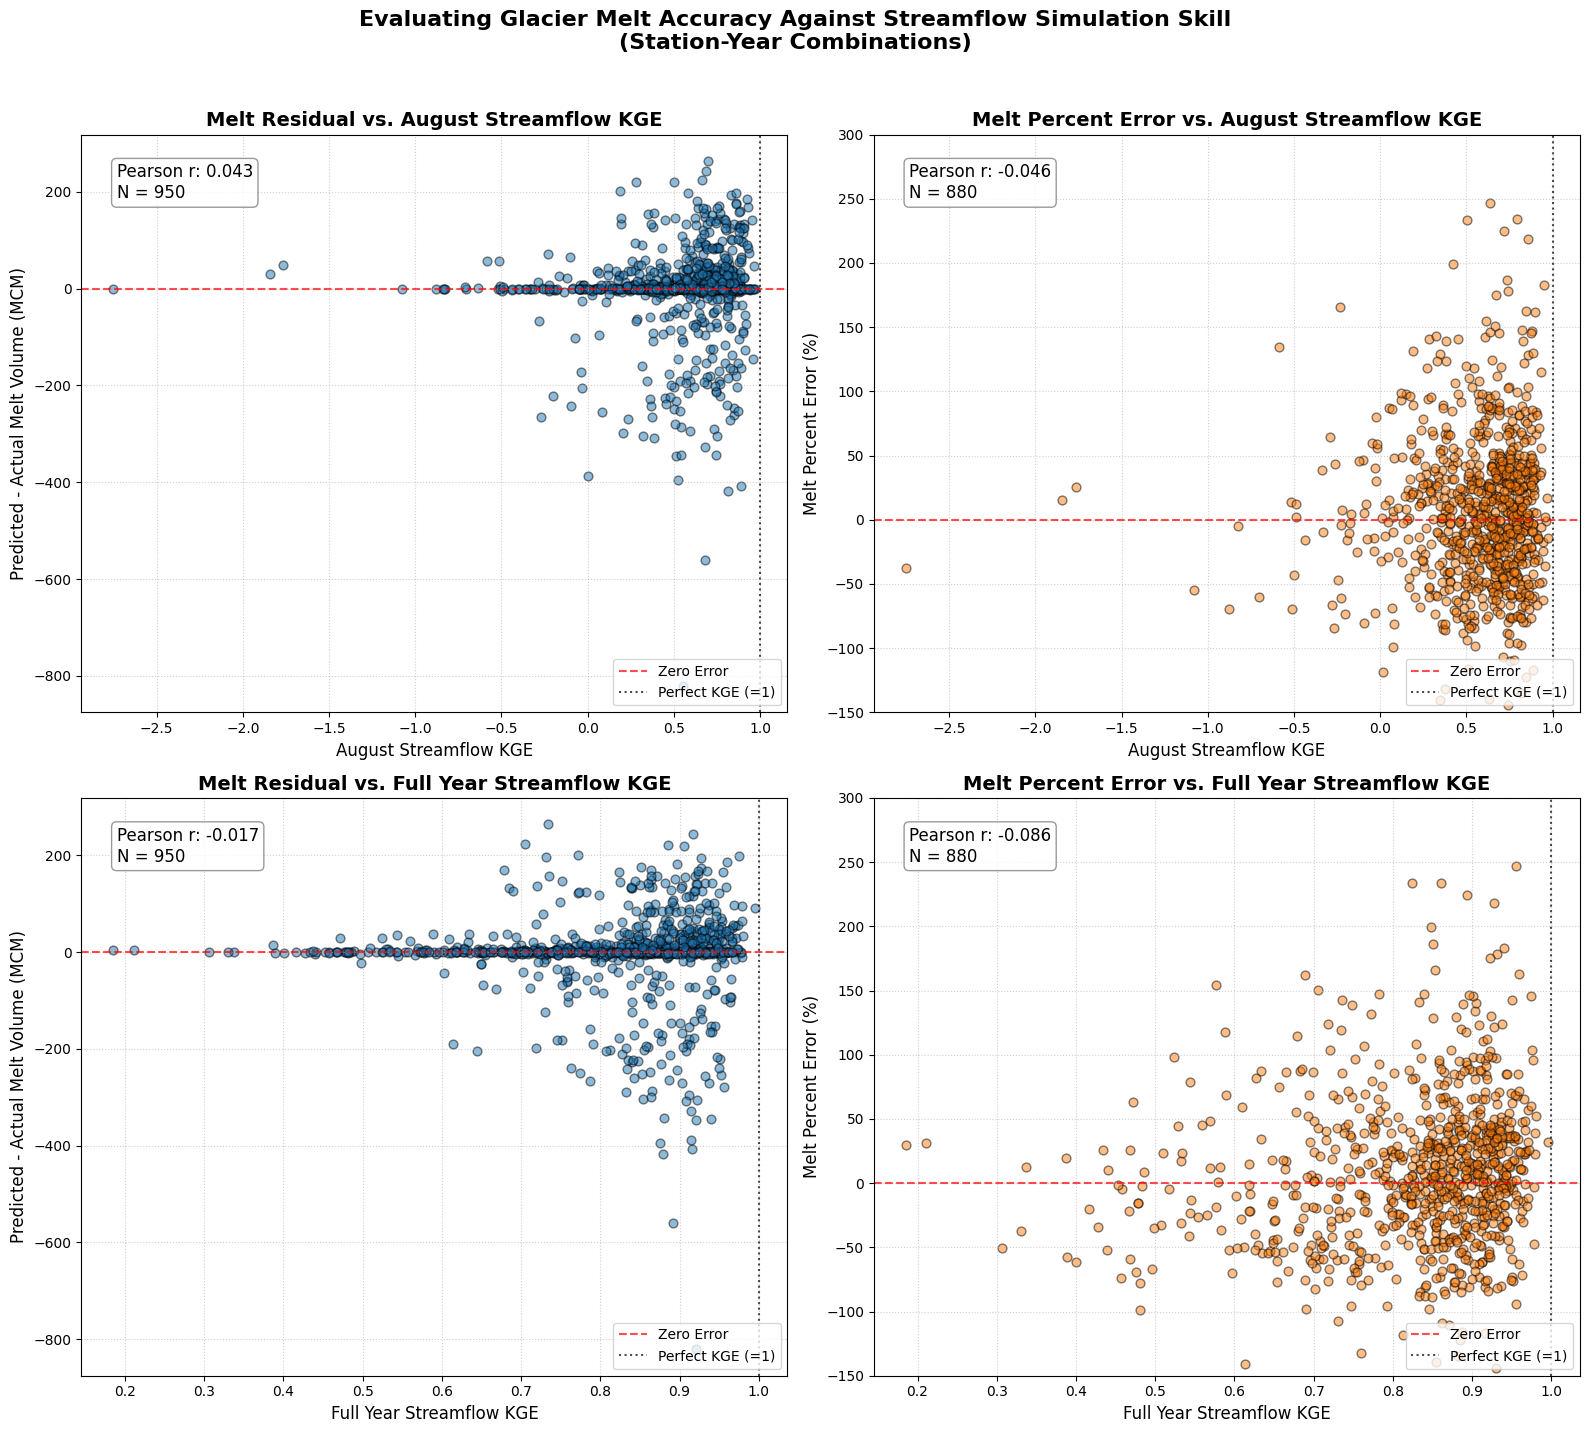

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore', category=RuntimeWarning)

# =========================================================
# 1. KGE Calculation Function
# =========================================================
def calc_kge(obs, sim):
    valid_mask = ~(np.isnan(obs) | np.isnan(sim))
    obs, sim = obs[valid_mask], sim[valid_mask]
    if len(obs) < 2 or np.std(obs) == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# =========================================================
# 2. Setup & Load Data
# =========================================================
print("Loading data and calculating ensemble means...")

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) # Native MCM

# Get template for test dates/stations
df_test_template = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
test_dates = df_test_template.index

glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_test_template.columns).intersection(df_mb.columns).intersection(df_obs.columns)

df_obs_test = df_obs.loc[test_dates, common_stations].copy()

# --- THE FIX ---
# Since df_mb is monthly, we CANNOT slice it with the daily test_dates index.
# We just isolate the common stations and leave the monthly index intact.
df_mb_test = df_mb[common_stations].copy()

# Convert Obs to mm/day
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']
for stat in common_stations:
    df_obs_test[stat] = df_obs_test[stat] * (86.4 / basin_areas[stat])

# --- Calculate Ensemble Means ---
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
list_pred, list_noglac = [], []

for i in range(10):
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)
    list_pred.append(pred.loc[test_dates, common_stations])
    list_noglac.append(noglac.loc[test_dates, common_stations])

df_pred_mean = sum(list_pred) / 10
df_noglac_mean = sum(list_noglac) / 10

# =========================================================
# 3. Calculate Station-Yearly Metrics
# =========================================================
print("Calculating KGE and Melt Residuals per Station-Year...")
test_years = np.unique(test_dates.year)
records = []

for y in test_years:
    for s in common_stations:
        # Timeseries slices
        obs_y = df_obs_test.loc[str(y), s].values
        pred_y = df_pred_mean.loc[str(y), s].values
        
        obs_aug = df_obs_test.loc[f"{y}-08", s].values
        pred_aug = df_pred_mean.loc[f"{y}-08", s].values
        
        # Calculate KGEs
        kge_year = calc_kge(obs_y, pred_y)
        kge_aug = calc_kge(obs_aug, pred_aug)
        
        # Calculate Melt Volumes (MCM)
        pred_melt_mm_sum = df_pred_mean.loc[f"{y}-08", s].sum() - df_noglac_mean.loc[f"{y}-08", s].sum()
        pred_melt_mcm = pred_melt_mm_sum * basin_areas[s] * 0.001
        
        # Extract Actual Melt from the monthly dataframe
        act_melt_mcm = df_mb_test.loc[f"{y}-08", s].sum()
        
        # Residuals
        residual_mcm = pred_melt_mcm - act_melt_mcm
        
        # Percent Error (protect against zero-division)
        if act_melt_mcm > 0.0001: 
            pct_error = (residual_mcm / act_melt_mcm) * 100
        else:
            pct_error = np.nan
            
        records.append({
            'Station': s, 'Year': y,
            'KGE_Aug': kge_aug, 'KGE_Year': kge_year,
            'Residual_MCM': residual_mcm, 'Pct_Error': pct_error
        })

df_res = pd.DataFrame(records)

# Clean out infinite values from extreme % error cases
df_res.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================================================
# 4. Helper for Plotting
# =========================================================
def get_clean_data(df, x_col, y_col):
    mask = ~(df[x_col].isna() | df[y_col].isna())
    clean_df = df[mask]
    x = clean_df[x_col].values
    y = clean_df[y_col].values
    corr, _ = stats.pearsonr(x, y)
    return x, y, corr

# =========================================================
# 5. Plotting (2x2 Grid)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')

def plot_panel(ax, x_col, y_col, title, xlabel, ylabel, color, use_ylim=None):
    x, y, corr = get_clean_data(df_res, x_col, y_col)
    
    ax.scatter(x, y, color=color, alpha=0.5, edgecolor='k', s=40)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Add correlation text
    ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}\nN = {len(x)}', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', bbox=props)
            
    # Reference Lines
    ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Error')
    ax.axvline(1, color='black', linestyle=':', alpha=0.7, label='Perfect KGE (=1)')
    
    if use_ylim:
        ax.set_ylim(use_ylim)
        
    ax.legend(loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.6)

# --- Row 1: August KGE ---
plot_panel(axes[0, 0], 'KGE_Aug', 'Residual_MCM', 
           'Melt Residual vs. August Streamflow KGE', 
           'August Streamflow KGE', 'Predicted - Actual Melt Volume (MCM)', 'tab:blue')

plot_panel(axes[0, 1], 'KGE_Aug', 'Pct_Error', 
           'Melt Percent Error vs. August Streamflow KGE', 
           'August Streamflow KGE', 'Melt Percent Error (%)', 'tab:orange', use_ylim=(-150, 300))

# --- Row 2: Full Year KGE ---
plot_panel(axes[1, 0], 'KGE_Year', 'Residual_MCM', 
           'Melt Residual vs. Full Year Streamflow KGE', 
           'Full Year Streamflow KGE', 'Predicted - Actual Melt Volume (MCM)', 'tab:blue')

plot_panel(axes[1, 1], 'KGE_Year', 'Pct_Error', 
           'Melt Percent Error vs. Full Year Streamflow KGE', 
           'Full Year Streamflow KGE', 'Melt Percent Error (%)', 'tab:orange', use_ylim=(-150, 300))

plt.suptitle('Evaluating Glacier Melt Accuracy Against Streamflow Simulation Skill\n(Station-Year Combinations)', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

Loading data and calculating ensemble means for 1980-2022...
Calculating Yearly Error Metrics...


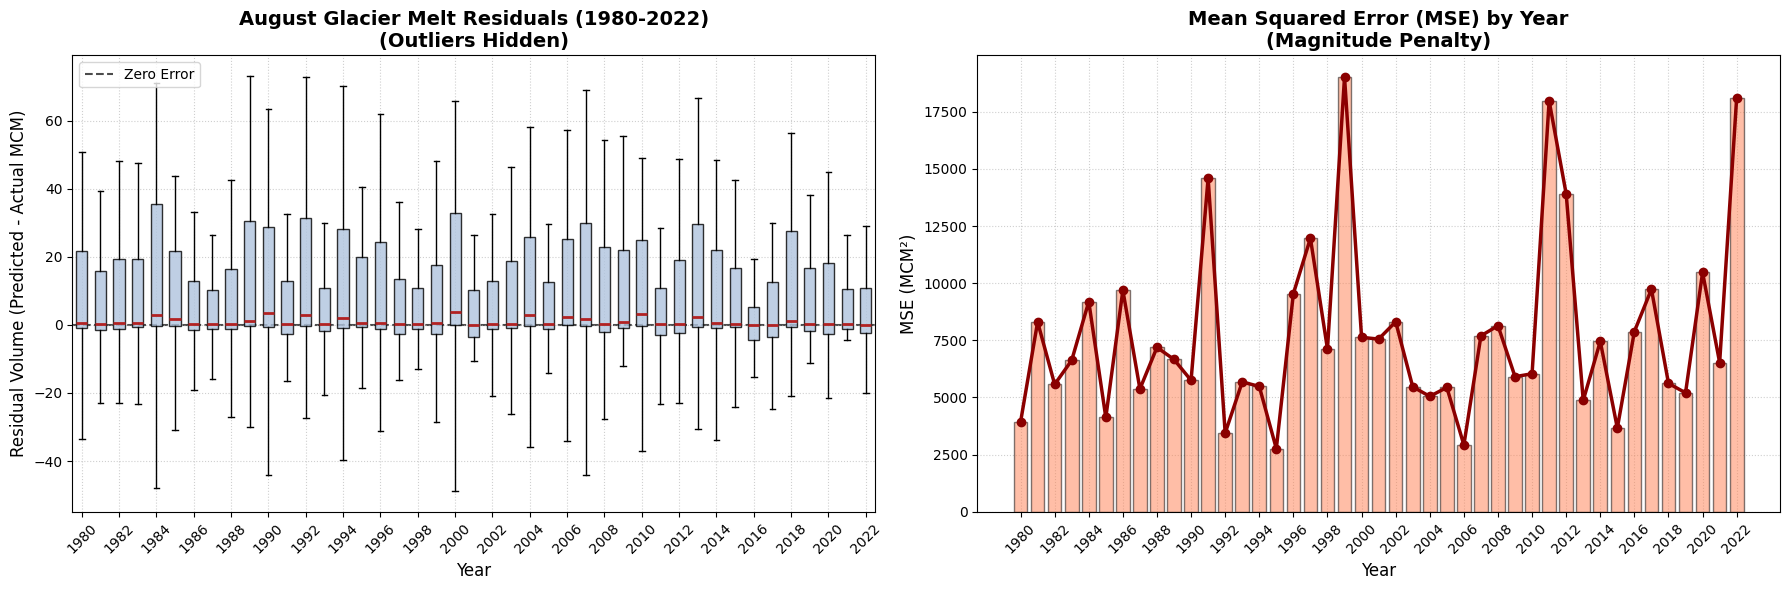

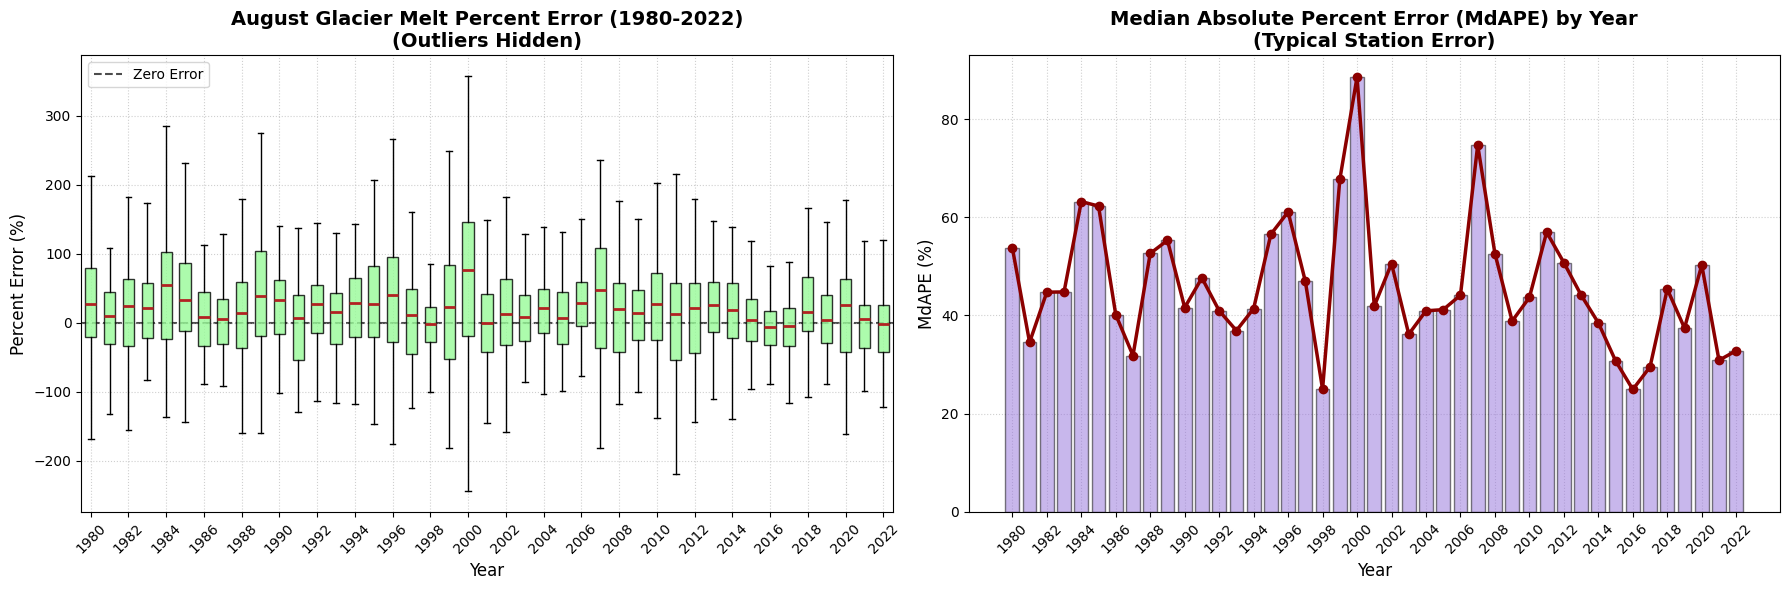

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Setup & Load Data (Full Timeline)
# =========================================================
print("Loading data and calculating ensemble means for 1980-2022...")

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) # Native MCM

# Identify glaciated stations
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index

# Load ONE template just to get the columns (stations) available in the predictions
template = pd.read_csv(OUTPUT_DATA_DIR / "phase_split" / "phase-split_preds_member_0.csv", index_col=0, nrows=1)
common_stations = glaciated_stations.intersection(template.columns).intersection(df_mb.columns)

df_mb_full = df_mb[common_stations].copy()
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# =========================================================
# 2. Calculate Ensemble Means & Melt Volumes (1980-2022)
# =========================================================
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
list_pred, list_noglac = [], []

for i in range(10):
    # Load full timeline
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    list_pred.append(pred)
    list_noglac.append(noglac)

# Ensemble Mean (mm/day)
df_pred_mean = sum(list_pred) / 10
df_noglac_mean = sum(list_noglac) / 10

# Calculate daily difference (mm/day)
df_diff_mm = df_pred_mean - df_noglac_mean

# Isolate August and calculate monthly sum (mm/month)
df_diff_aug_mm = df_diff_mm[df_diff_mm.index.month == 8].groupby(df_diff_mm[df_diff_mm.index.month == 8].index.year).sum()

# Convert predicted depth to volume (MCM)
df_pred_mcm = df_diff_aug_mm * basin_areas * 0.001

# Extract Actual MCM
df_act_mcm = df_mb_full[df_mb_full.index.month == 8].groupby(df_mb_full[df_mb_full.index.month == 8].index.year).sum()

# Align years strictly to 1980-2022
common_years = df_act_mcm.index.intersection(df_pred_mcm.index)
common_years = common_years[(common_years >= 1980) & (common_years <= 2022)]

df_pred_mcm = df_pred_mcm.loc[common_years]
df_act_mcm = df_act_mcm.loc[common_years]

# =========================================================
# 3. Calculate Errors (Residuals, MSE, Pct Error, MdAPE)
# =========================================================
print("Calculating Yearly Error Metrics...")

years = common_years.tolist()

# --- Absolute Residuals (MCM) ---
df_residual = df_pred_mcm - df_act_mcm
mse_per_year = (df_residual ** 2).mean(axis=1)

# --- Percent Errors (%) ---
# Mask out actual melt values that are too close to zero to prevent infinity/massive spikes
safe_act_mcm = df_act_mcm.copy()
safe_act_mcm[safe_act_mcm < 0.01] = np.nan 

df_pct_error = (df_residual / safe_act_mcm) * 100

# Use Median Absolute Percent Error (MdAPE) because the Mean is too sensitive to outliers
mdape_per_year = df_pct_error.abs().median(axis=1)

# Prepare lists of non-NaN arrays for the boxplots
res_data = [df_residual.loc[y].dropna().values for y in years]
pct_data = [df_pct_error.loc[y].dropna().values for y in years]

# =========================================================
# 4. Plotting Function
# =========================================================
def plot_yearly_metrics(box_data, line_data, years, 
                        box_ylabel, line_ylabel, box_title, line_title, 
                        box_color, line_color, is_percent=False):
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # --- Boxplot ---
    # showfliers=False removes the outliers from the visualization
    bp = axes[0].boxplot(box_data, positions=years, patch_artist=True, widths=0.6, showfliers=False,
                         boxprops=dict(facecolor=box_color, color='black', alpha=0.8),
                         capprops=dict(color='black'),
                         whiskerprops=dict(color='black'),
                         medianprops=dict(color='firebrick', linewidth=2))

    axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0, label='Zero Error')
    axes[0].set_title(box_title, fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel(box_ylabel, fontsize=12)
    axes[0].set_xticks(years[::2]) # Show every other year to prevent crowding
    axes[0].set_xticklabels(years[::2], rotation=45)
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend(loc='upper left')

    # --- Bar/Line Plot ---
    axes[1].bar(years, line_data.values, color=line_color, alpha=0.5, edgecolor='black', zorder=2)
    axes[1].plot(years, line_data.values, color='darkred', marker='o', linewidth=2.5, markersize=6, zorder=3)
    
    axes[1].set_title(line_title, fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Year', fontsize=12)
    axes[1].set_ylabel(line_ylabel, fontsize=12)
    axes[1].set_xticks(years[::2])
    axes[1].set_xticklabels(years[::2], rotation=45)
    axes[1].grid(True, linestyle=':', alpha=0.6, zorder=0)
    
    plt.tight_layout()
    plt.show()

# =========================================================
# 5. Generate Figures
# =========================================================

# FIGURE 1: Residuals & MSE
plot_yearly_metrics(
    box_data=res_data, line_data=mse_per_year, years=years,
    box_ylabel='Residual Volume (Predicted - Actual MCM)', 
    line_ylabel='MSE (MCM²)',
    box_title='August Glacier Melt Residuals (1980-2022)\n(Outliers Hidden)', 
    line_title='Mean Squared Error (MSE) by Year\n(Magnitude Penalty)',
    box_color='lightsteelblue', line_color='coral'
)

# FIGURE 2: Percent Error & Absolute Percent Error (MdAPE)
plot_yearly_metrics(
    box_data=pct_data, line_data=mdape_per_year, years=years,
    box_ylabel='Percent Error (%)', 
    line_ylabel='MdAPE (%)',
    box_title='August Glacier Melt Percent Error (1980-2022)\n(Outliers Hidden)', 
    line_title='Median Absolute Percent Error (MdAPE) by Year\n(Typical Station Error)',
    box_color='palegreen', line_color='mediumpurple', is_percent=True
)

Interestingly, we have the most error centered around 2000. Would've expected 2000 to be lower. I expect this is probably pretty dependent on seasonality and also how much the glacier area actually changed. Will want to work with a dataset of the actual ice change to see

Loading data for Station 05DA009...
Calculating ensemble predictions and uncertainties...
Generating plots...


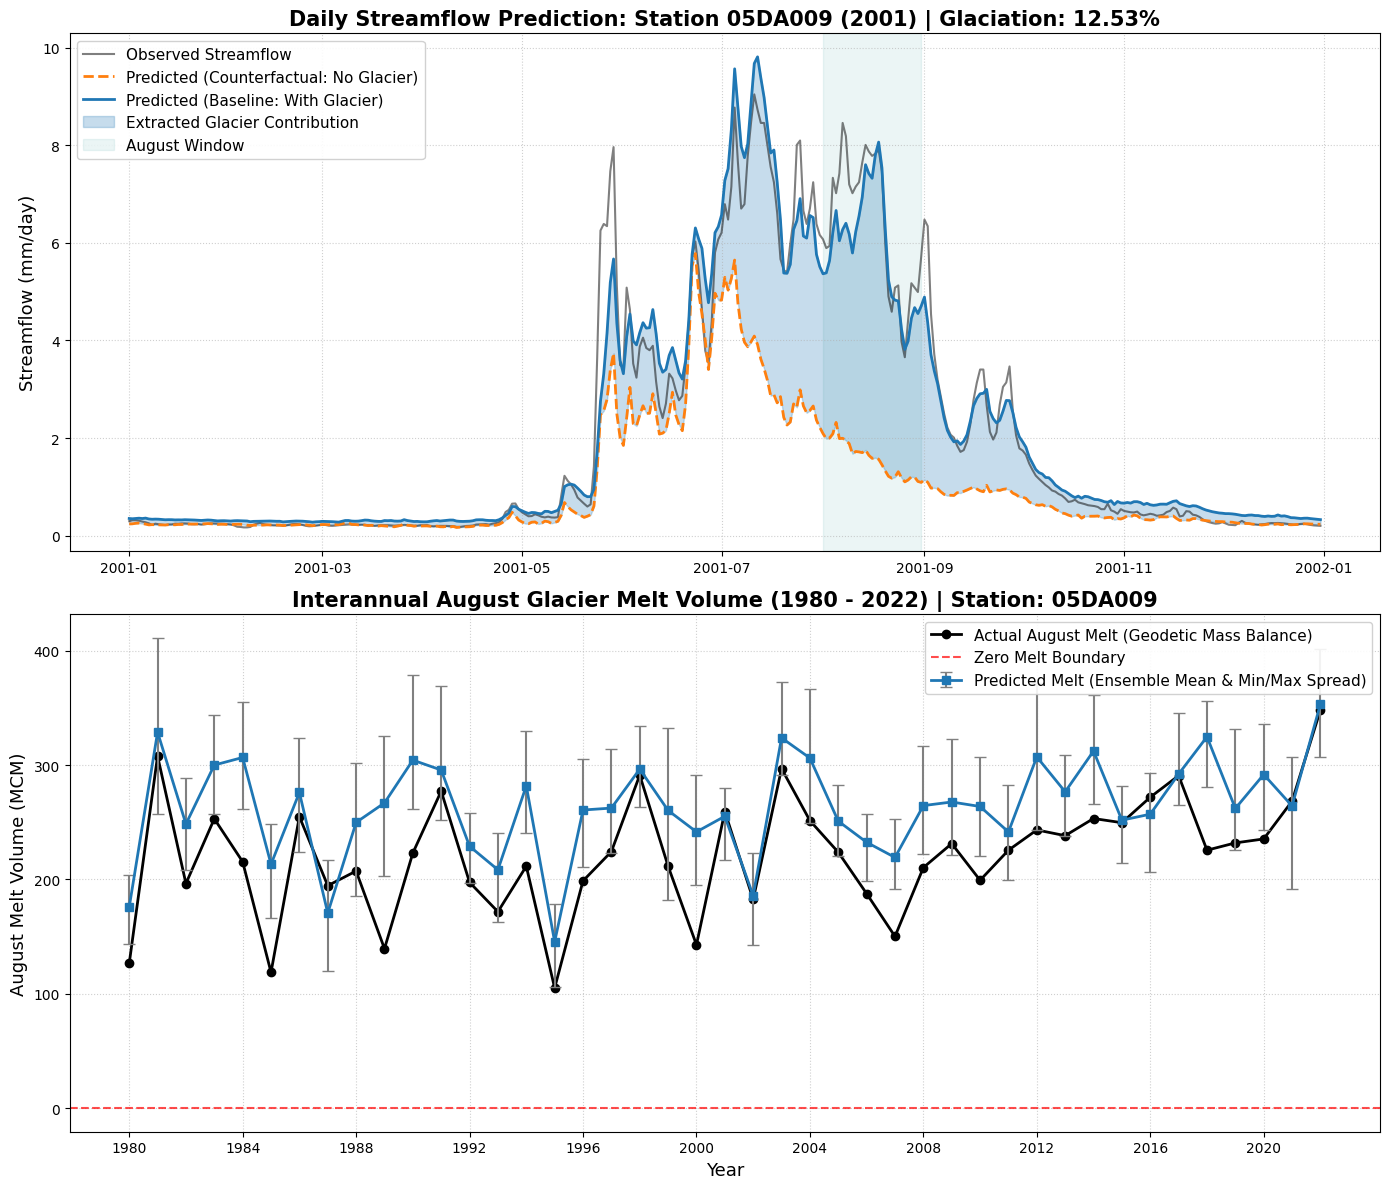

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. USER INPUTS
# =========================================================
TARGET_STATION = '05DA009'  # Change to explore different stations
TARGET_YEAR = 2001          # Change to explore different years

# =========================================================
# 2. Load Static Data and Observations
# =========================================================
print(f"Loading data for Station {TARGET_STATION}...")

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) 
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)

basin_area = df_attr.loc[TARGET_STATION, 'basin_area_km2']
glac_pct = df_attr.loc[TARGET_STATION, 'glacier_pct']

# Convert observation to mm/day
obs_series = df_obs[TARGET_STATION] * (86.4 / basin_area)

# Extract Actual August MCM for all years (1980-2022)
act_aug_mcm = df_mb[TARGET_STATION][df_mb.index.month == 8].groupby(df_mb[df_mb.index.month == 8].index.year).sum()

# =========================================================
# 3. Process Ensemble Predictions (Phase-Split Model)
# =========================================================
print("Calculating ensemble predictions and uncertainties...")
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"

list_pred_series = []
list_noglac_series = []
list_aug_mcm_yearly = []

for i in range(10):
    # Load specific ensemble members and immediately subset to target station to save RAM
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[TARGET_STATION]
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[TARGET_STATION]
    
    list_pred_series.append(pred)
    list_noglac_series.append(noglac)
    
    # Calculate yearly August MCM for THIS specific ensemble member
    diff_mm = pred - noglac
    aug_diff_mm = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
    aug_mcm = aug_diff_mm * basin_area * 0.001
    list_aug_mcm_yearly.append(aug_mcm)

# Aggregate daily streamflow across the ensemble (For Plot 1)
df_pred_daily = pd.concat(list_pred_series, axis=1)
df_noglac_daily = pd.concat(list_noglac_series, axis=1)

mean_pred_daily = df_pred_daily.mean(axis=1)
mean_noglac_daily = df_noglac_daily.mean(axis=1)

# Aggregate yearly August melt across the ensemble (For Plot 2)
df_aug_yearly = pd.concat(list_aug_mcm_yearly, axis=1)

# Ensure years align with actual mass balance
common_years = df_aug_yearly.index.intersection(act_aug_mcm.index)
df_aug_yearly = df_aug_yearly.loc[common_years]
act_aug_mcm = act_aug_mcm.loc[common_years]

# Calculate Mean and Error Bounds
mean_aug_mcm = df_aug_yearly.mean(axis=1)
min_aug_mcm = df_aug_yearly.min(axis=1)
max_aug_mcm = df_aug_yearly.max(axis=1)

# Calculate asymmetric error bars for matplotlib (requires [lower_errors, upper_errors])
err_lower = mean_aug_mcm - min_aug_mcm
err_upper = max_aug_mcm - mean_aug_mcm
yerr = [err_lower.values, err_upper.values]

# =========================================================
# 4. Plotting
# =========================================================
print("Generating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1]})

# ---------------------------------------------------------
# PANEL 1: Daily Hydrograph with Shaded Glacier Contribution
# ---------------------------------------------------------
year_mask = mean_pred_daily.index.year == TARGET_YEAR
dates_yr = mean_pred_daily[year_mask].index

pred_yr = mean_pred_daily[year_mask]
noglac_yr = mean_noglac_daily[year_mask]
obs_yr = obs_series[year_mask]

ax1.plot(dates_yr, obs_yr, color='black', alpha=0.5, label='Observed Streamflow', linewidth=1.5)
ax1.plot(dates_yr, noglac_yr, color='tab:orange', linestyle='--', label='Predicted (Counterfactual: No Glacier)', linewidth=2)
ax1.plot(dates_yr, pred_yr, color='tab:blue', label='Predicted (Baseline: With Glacier)', linewidth=2)

# Shade the area ONLY where With Glacier > Without Glacier
ax1.fill_between(dates_yr, noglac_yr, pred_yr, where=(pred_yr > noglac_yr), 
                 interpolate=True, color='tab:blue', alpha=0.25, label='Extracted Glacier Contribution')

# Highlight August Window
aug_start = pd.to_datetime(f"{TARGET_YEAR}-08-01")
aug_end = pd.to_datetime(f"{TARGET_YEAR}-08-31")
ax1.axvspan(aug_start, aug_end, color='teal', alpha=0.08, label='August Window')

ax1.set_title(f"Daily Streamflow Prediction: Station {TARGET_STATION} ({TARGET_YEAR}) | Glaciation: {glac_pct:.2f}%", fontsize=15, fontweight='bold')
ax1.set_ylabel("Streamflow (mm/day)", fontsize=13)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)

# ---------------------------------------------------------
# PANEL 2: Interannual August Melt Time Series w/ Error Bars
# ---------------------------------------------------------
years = common_years.values

# Plot the Actual Mass Balance (Ground Truth)
ax2.plot(years, act_aug_mcm.values, color='black', marker='o', linestyle='-', linewidth=2, markersize=6, label='Actual August Melt (Geodetic Mass Balance)')

# Plot the Predicted Mean with Ensemble Error Bars
ax2.errorbar(years, mean_aug_mcm.values, yerr=yerr, fmt='s-', color='tab:blue', linewidth=2, capsize=4, 
             ecolor='gray', elinewidth=1.5, markersize=6, label='Predicted Melt (Ensemble Mean & Min/Max Spread)')

ax2.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Melt Boundary')

ax2.set_title(f"Interannual August Glacier Melt Volume (1980 - 2022) | Station: {TARGET_STATION}", fontsize=15, fontweight='bold')
ax2.set_ylabel("August Melt Volume (MCM)", fontsize=13)
ax2.set_xlabel("Year", fontsize=13)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Fix x-axis ticks to show round years cleanly
ax2.set_xticks(np.arange(min(years), max(years)+1, 4))

plt.tight_layout()
plt.show()

Loading static attributes, metadata, and valid stations...
Calculating ensemble predictions...
Calculating spatial performance metrics per station...
Aggregating total regional mass balance...
Generating Spatial Plot...


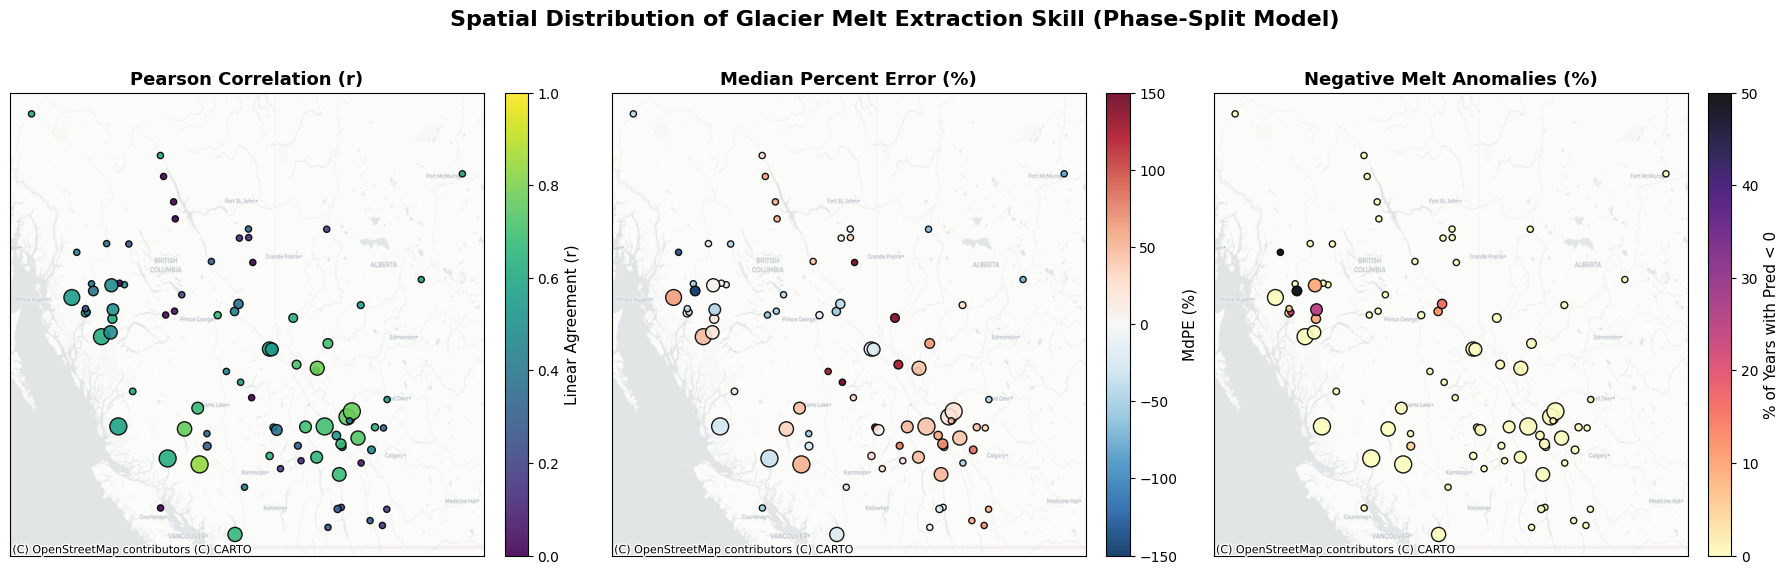

Generating Regional Time Series Plot...


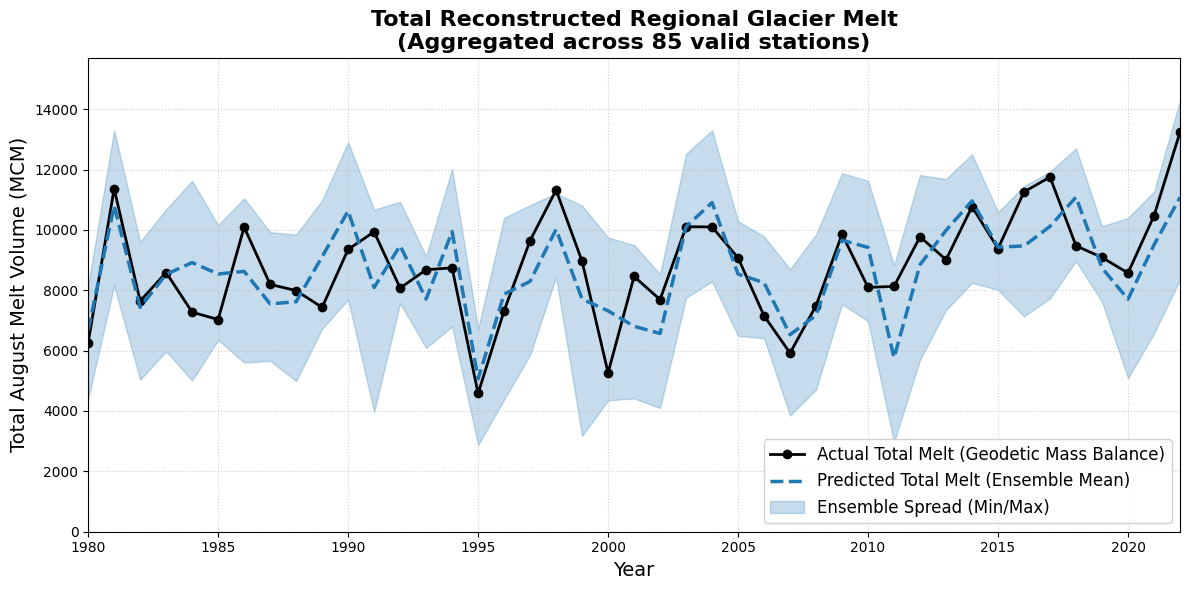

In [12]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
import warnings
from pathlib import Path

# Added RAW_DATA_DIR to the import
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, RAW_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Setup and Load Data
# =========================================================
print("Loading static attributes, metadata, and valid stations...")

# Load valid glaciated stations
with open(PROCESSED_DATA_DIR / "valid_glaciated_stations.txt", "r") as f:
    valid_stations = [line.strip() for line in f.readlines()]

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) 

# Load Geographic Metadata (assuming station ID is the index)
df_meta = pd.read_csv(RAW_DATA_DIR / "station_metadata.csv", index_col=0)

common_stations = df_attr.index.intersection(df_mb.columns).intersection(valid_stations)

df_mb_full = df_mb[common_stations].copy()
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# Extract Actual August MCM for the 1980-2022 period
df_act_mcm = df_mb_full[df_mb_full.index.month == 8].groupby(df_mb_full[df_mb_full.index.month == 8].index.year).sum()
df_act_mcm = df_act_mcm[(df_act_mcm.index >= 1980) & (df_act_mcm.index <= 2022)]

# =========================================================
# 2. Extract Ensemble Predictions
# =========================================================
print("Calculating ensemble predictions...")
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"

# Store the yearly August MCM predictions for each ensemble member
ens_pred_mcm_list = []

for i in range(10):
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    
    diff_mm = pred - noglac
    diff_aug_mm = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
    
    pred_mcm = diff_aug_mm * basin_areas * 0.001
    pred_mcm = pred_mcm[(pred_mcm.index >= 1980) & (pred_mcm.index <= 2022)]
    ens_pred_mcm_list.append(pred_mcm)

# Calculate the Ensemble Mean Prediction for the Spatial Plots
df_pred_mean_mcm = sum(ens_pred_mcm_list) / 10

# Create a mask so we only evaluate predictions where we have actual ground truth
valid_mask = df_act_mcm.notna()
df_pred_mean_mcm = df_pred_mean_mcm.where(valid_mask)

# =========================================================
# 3. Calculate Spatial Metrics per Station
# =========================================================
print("Calculating spatial performance metrics per station...")

spatial_metrics = []

for stat in common_stations:
    act = df_act_mcm[stat].dropna().values
    pred = df_pred_mean_mcm[stat].dropna().values
    
    if len(act) > 2:
        # Correlation
        r, _ = stats.pearsonr(act, pred)
        
        # Median Percent Error (MdPE)
        safe_mask = act > 0.01
        if np.sum(safe_mask) > 0:
            pct_errs = ((pred[safe_mask] - act[safe_mask]) / act[safe_mask]) * 100
            mdpe = np.median(pct_errs)
        else:
            mdpe = np.nan
            
        # Percentage of Negative Melt Predictions
        pct_neg = (np.sum(pred < 0) / len(pred)) * 100
        
        spatial_metrics.append({
            'Station': stat,
            'Lon': df_meta.loc[stat, 'Longitude'],  
            'Lat': df_meta.loc[stat, 'Latitude'],   
            'Glac_Pct': df_attr.loc[stat, 'glacier_pct'],
            'Pearson_r': r,
            'MdPE': mdpe,
            'Pct_Negative': pct_neg
        })

df_spatial = pd.DataFrame(spatial_metrics).dropna(subset=['Pearson_r'])

# Convert to GeoDataFrame
gdf_spatial = gpd.GeoDataFrame(
    df_spatial, 
    geometry=gpd.points_from_xy(df_spatial['Lon'], df_spatial['Lat']),
    crs="EPSG:4326" # Standard Lat/Lon coordinates
)

# Project to Web Mercator (Required for contextily basemaps)
gdf_spatial = gdf_spatial.to_crs(epsg=3857)

# =========================================================
# 4. Calculate Total Regional Time Series
# =========================================================
print("Aggregating total regional mass balance...")

# Sum the actual melt across all valid stations for each year
total_act_mcm_yearly = df_act_mcm.sum(axis=1)

# Sum the predicted melt across all valid stations for EACH ensemble member
total_pred_mcm_yearly_members = []
for ens_df in ens_pred_mcm_list:
    ens_df_masked = ens_df.where(valid_mask)
    total_pred_mcm_yearly_members.append(ens_df_masked.sum(axis=1))

df_total_preds = pd.concat(total_pred_mcm_yearly_members, axis=1)

# Calculate mean, min, and max for the error bars
total_mean_pred = df_total_preds.mean(axis=1)
total_min_pred = df_total_preds.min(axis=1)
total_max_pred = df_total_preds.max(axis=1)

# =========================================================
# 5. Plotting: Spatial Distribution with Maps
# =========================================================
print("Generating Spatial Plot...")
fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))
fig1.suptitle('Spatial Distribution of Glacier Melt Extraction Skill (Phase-Split Model)', fontsize=16, fontweight='bold', y=1.02)

# Scatter properties using the projected Web Mercator coordinates
x, y = gdf_spatial.geometry.x, gdf_spatial.geometry.y
sz = np.clip(gdf_spatial['Glac_Pct'] * 15, 20, 150) # Scale dot size by glaciation

# Choose a map style (CartoDB.Positron is clean and grey; OpenTopoMap shows mountains)
map_provider = cx.providers.CartoDB.Positron 

# Plot 1: Pearson Correlation
sc1 = ax1.scatter(x, y, c=gdf_spatial['Pearson_r'], cmap='viridis', s=sz, edgecolor='k', alpha=0.9, vmin=0, vmax=1)
ax1.set_title('Pearson Correlation (r)', fontsize=13, fontweight='bold')
plt.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04).set_label('Linear Agreement (r)', fontsize=11)
cx.add_basemap(ax1, source=map_provider, alpha=0.7)

# Plot 2: Median Percent Error (MdPE)
v_max = max(abs(gdf_spatial['MdPE'].min()), abs(gdf_spatial['MdPE'].max()))
v_max = np.clip(v_max, 0, 150) 
sc2 = ax2.scatter(x, y, c=gdf_spatial['MdPE'], cmap='RdBu_r', s=sz, edgecolor='k', alpha=0.9, vmin=-v_max, vmax=v_max)
ax2.set_title('Median Percent Error (%)', fontsize=13, fontweight='bold')
plt.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04).set_label('MdPE (%)', fontsize=11)
cx.add_basemap(ax2, source=map_provider, alpha=0.7)

# Plot 3: Percentage of Negative Melt
sc3 = ax3.scatter(x, y, c=gdf_spatial['Pct_Negative'], cmap='magma_r', s=sz, edgecolor='k', alpha=0.9, vmin=0, vmax=50)
ax3.set_title('Negative Melt Anomalies (%)', fontsize=13, fontweight='bold')
plt.colorbar(sc3, ax=ax3, fraction=0.046, pad=0.04).set_label('% of Years with Pred < 0', fontsize=11)
cx.add_basemap(ax3, source=map_provider, alpha=0.7)

# Clean up axes since Web Mercator coordinate labels are large and unhelpful visually
for ax in [ax1, ax2, ax3]:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# =========================================================
# 6. Plotting: Regional Time Series
# =========================================================
print("Generating Regional Time Series Plot...")
fig2, ax = plt.subplots(figsize=(12, 6))

years = total_act_mcm_yearly.index

# Plot Actual Sum
ax.plot(years, total_act_mcm_yearly.values, color='black', marker='o', linestyle='-', linewidth=2, 
        markersize=6, label='Actual Total Melt (Geodetic Mass Balance)')

# Plot Predicted Sum Line
ax.plot(years, total_mean_pred.values, color='tab:blue', linestyle='--', linewidth=2.5, 
        label='Predicted Total Melt (Ensemble Mean)')

# Shaded Error Region for Ensemble Spread
ax.fill_between(years, total_min_pred.values, total_max_pred.values, color='tab:blue', alpha=0.25, 
                label='Ensemble Spread (Min/Max)')

# Formatting
ax.set_title(f'Total Reconstructed Regional Glacier Melt\n(Aggregated across {len(common_stations)} valid stations)', fontsize=16, fontweight='bold')
ax.set_ylabel('Total August Melt Volume (MCM)', fontsize=14)
ax.set_xlabel('Year', fontsize=14)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=12, framealpha=0.9)
ax.set_xlim(years.min(), years.max())
ax.set_ylim(0, max(total_act_mcm_yearly.max(), total_max_pred.max()) * 1.1)

ax.set_xticks(np.arange(min(years), max(years)+1, 5))

plt.tight_layout()
plt.show()

Loading data and calculating metrics...
Generating Plots...


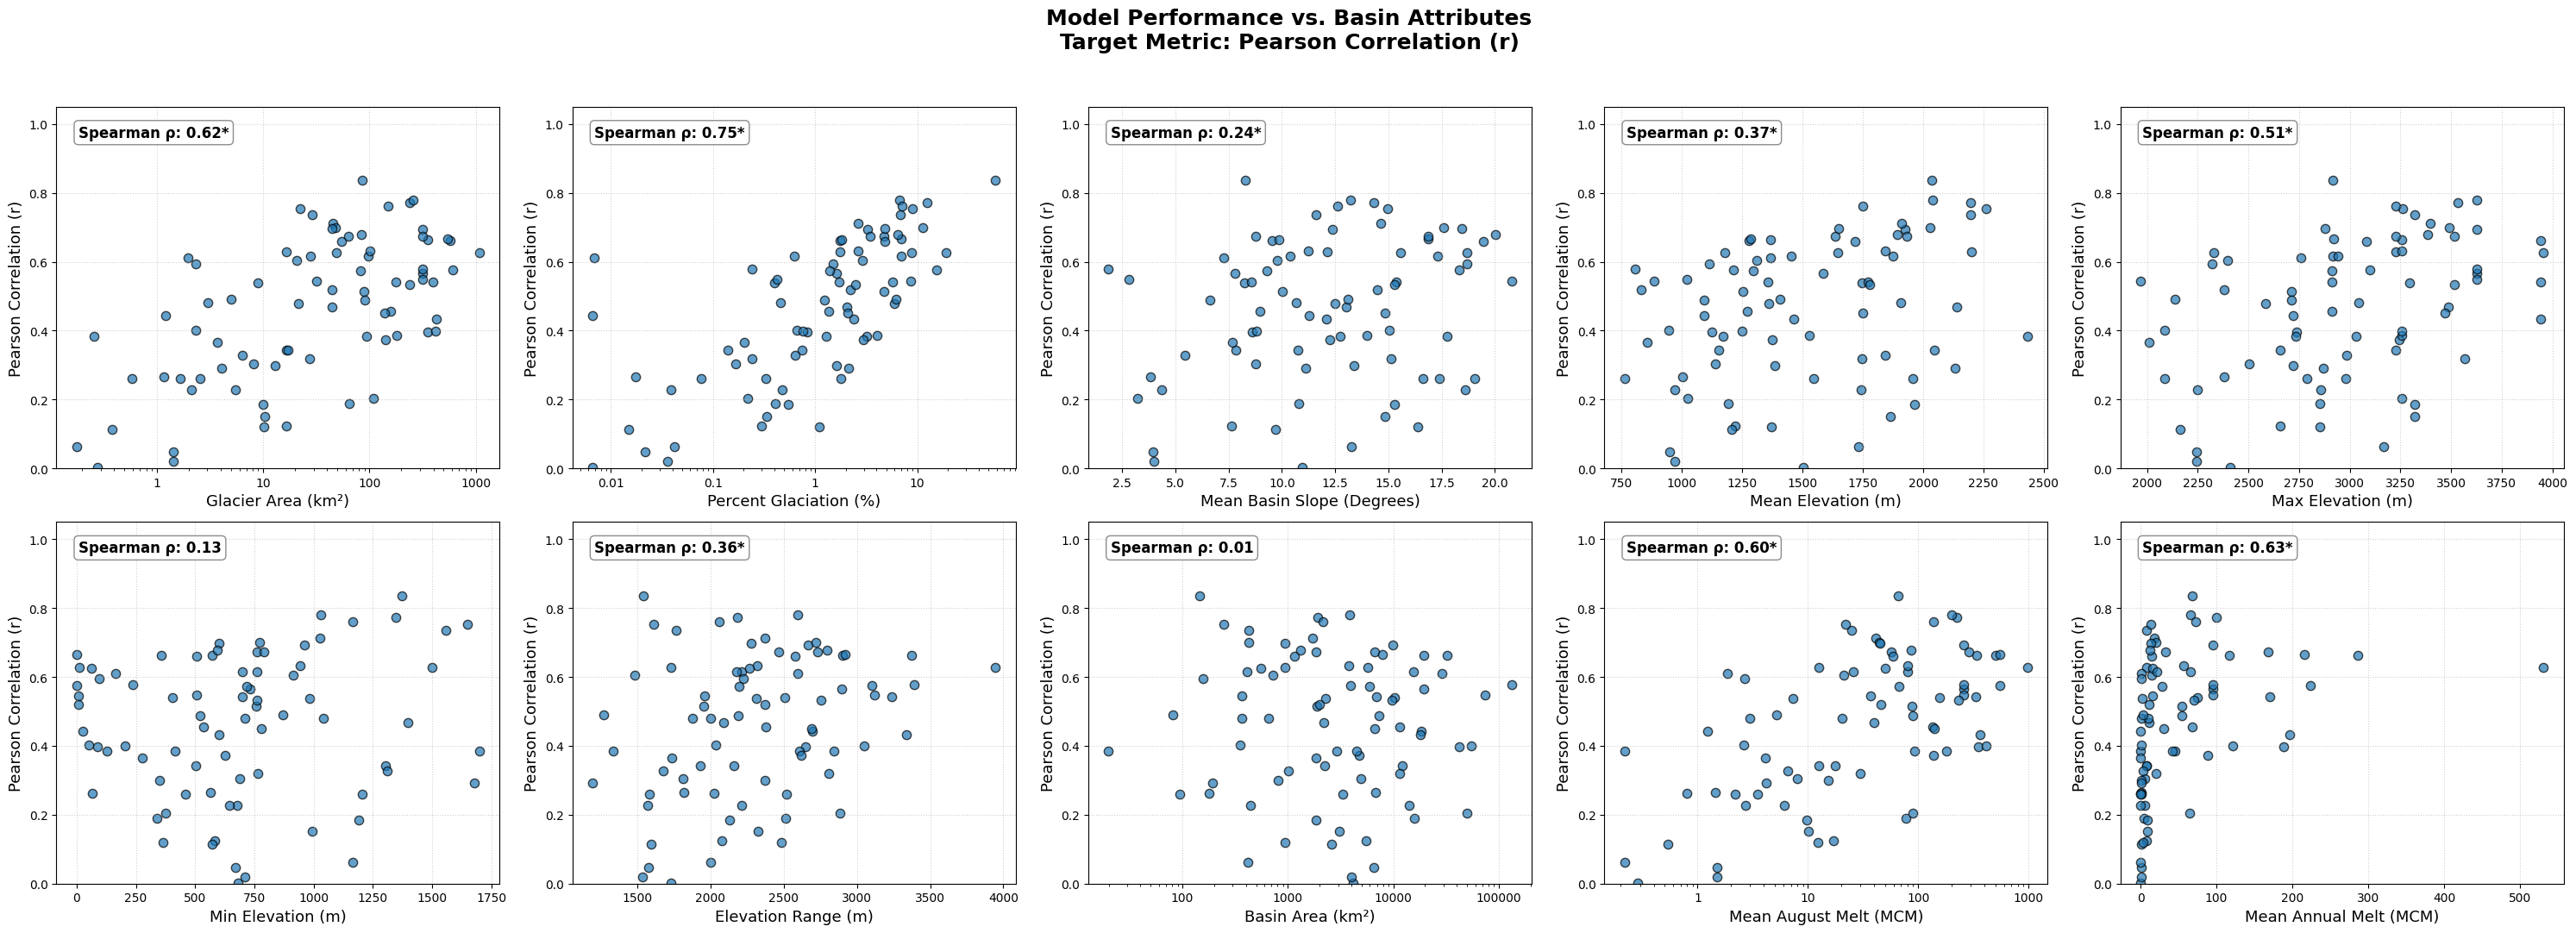

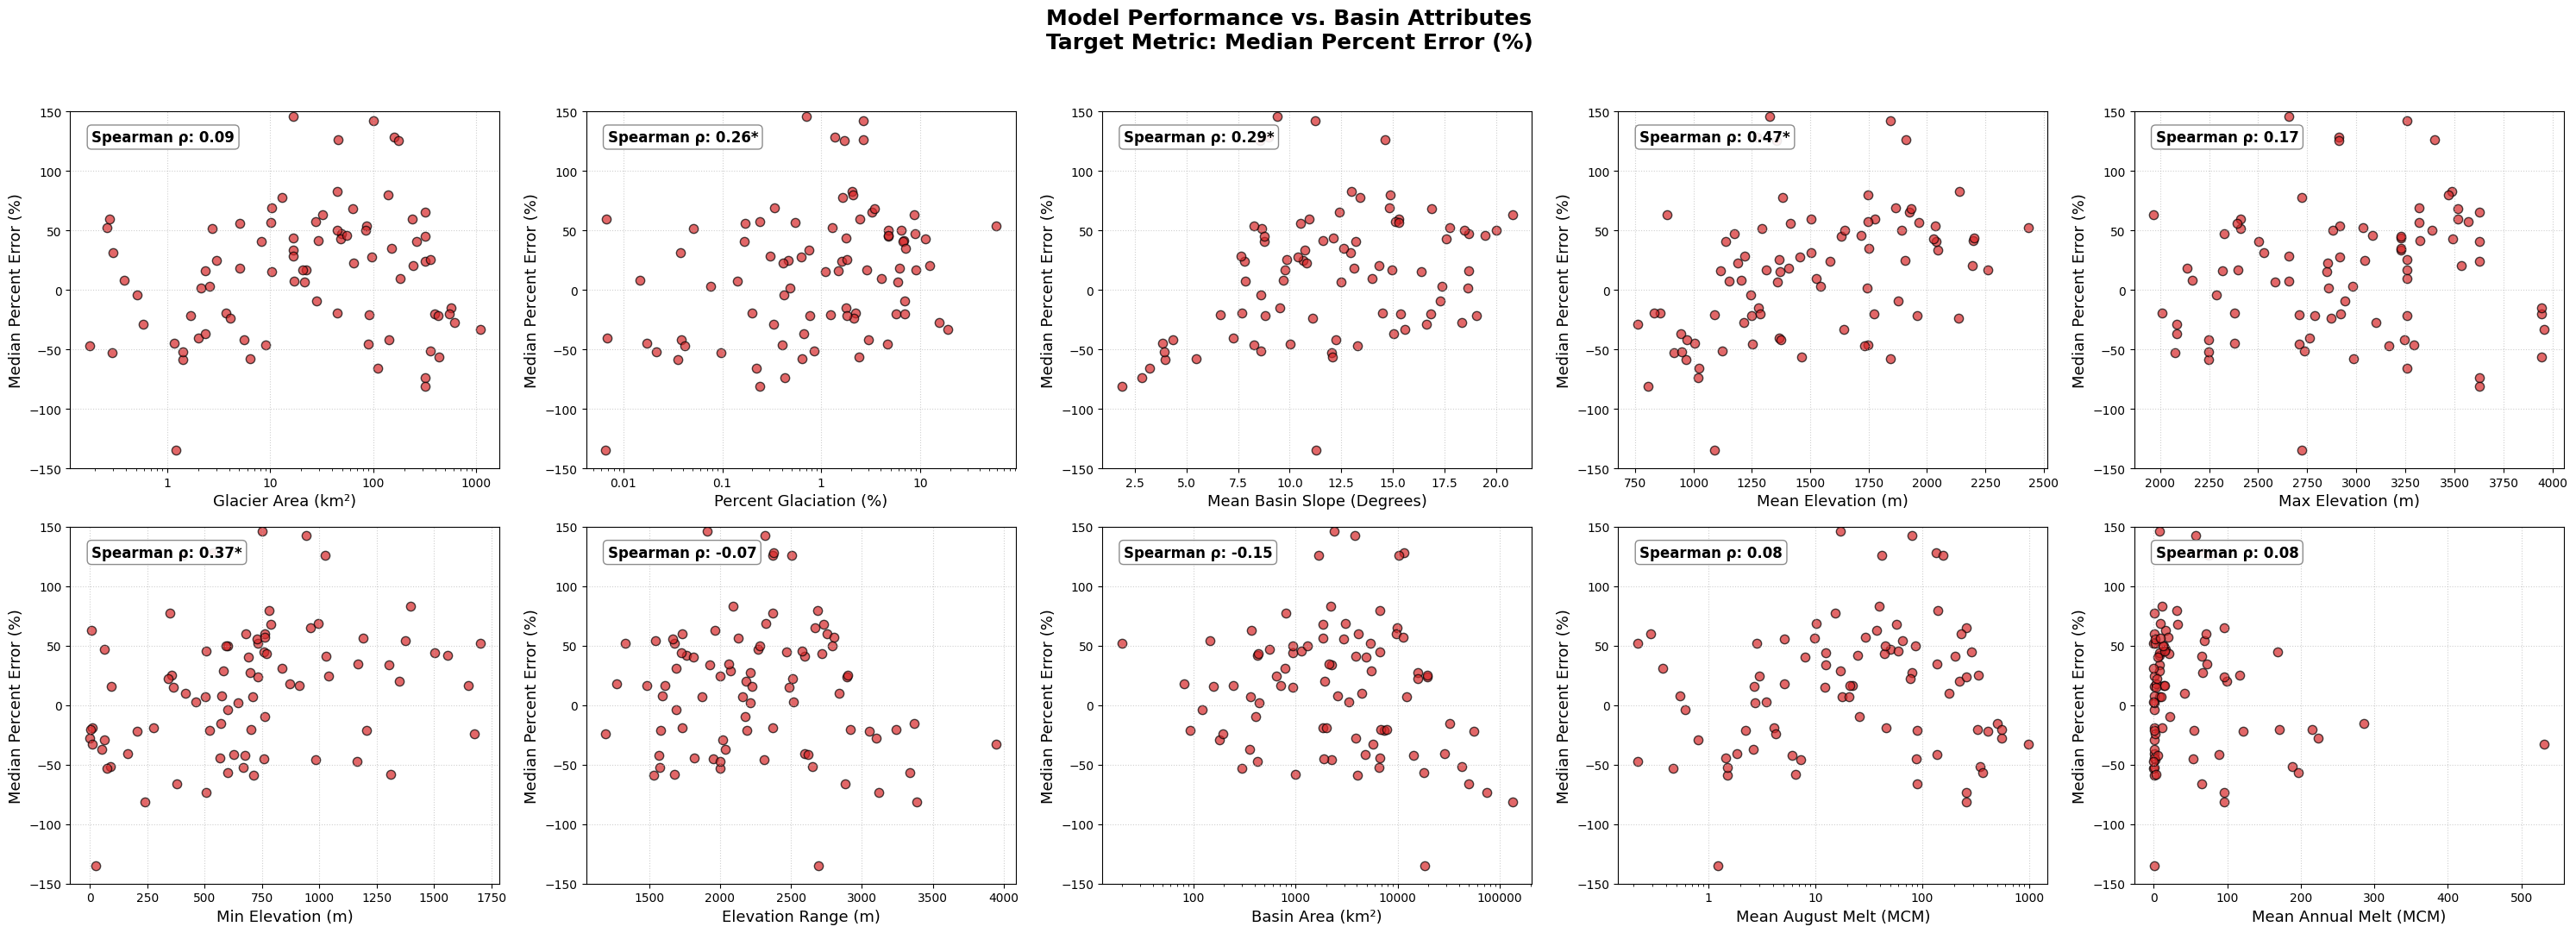

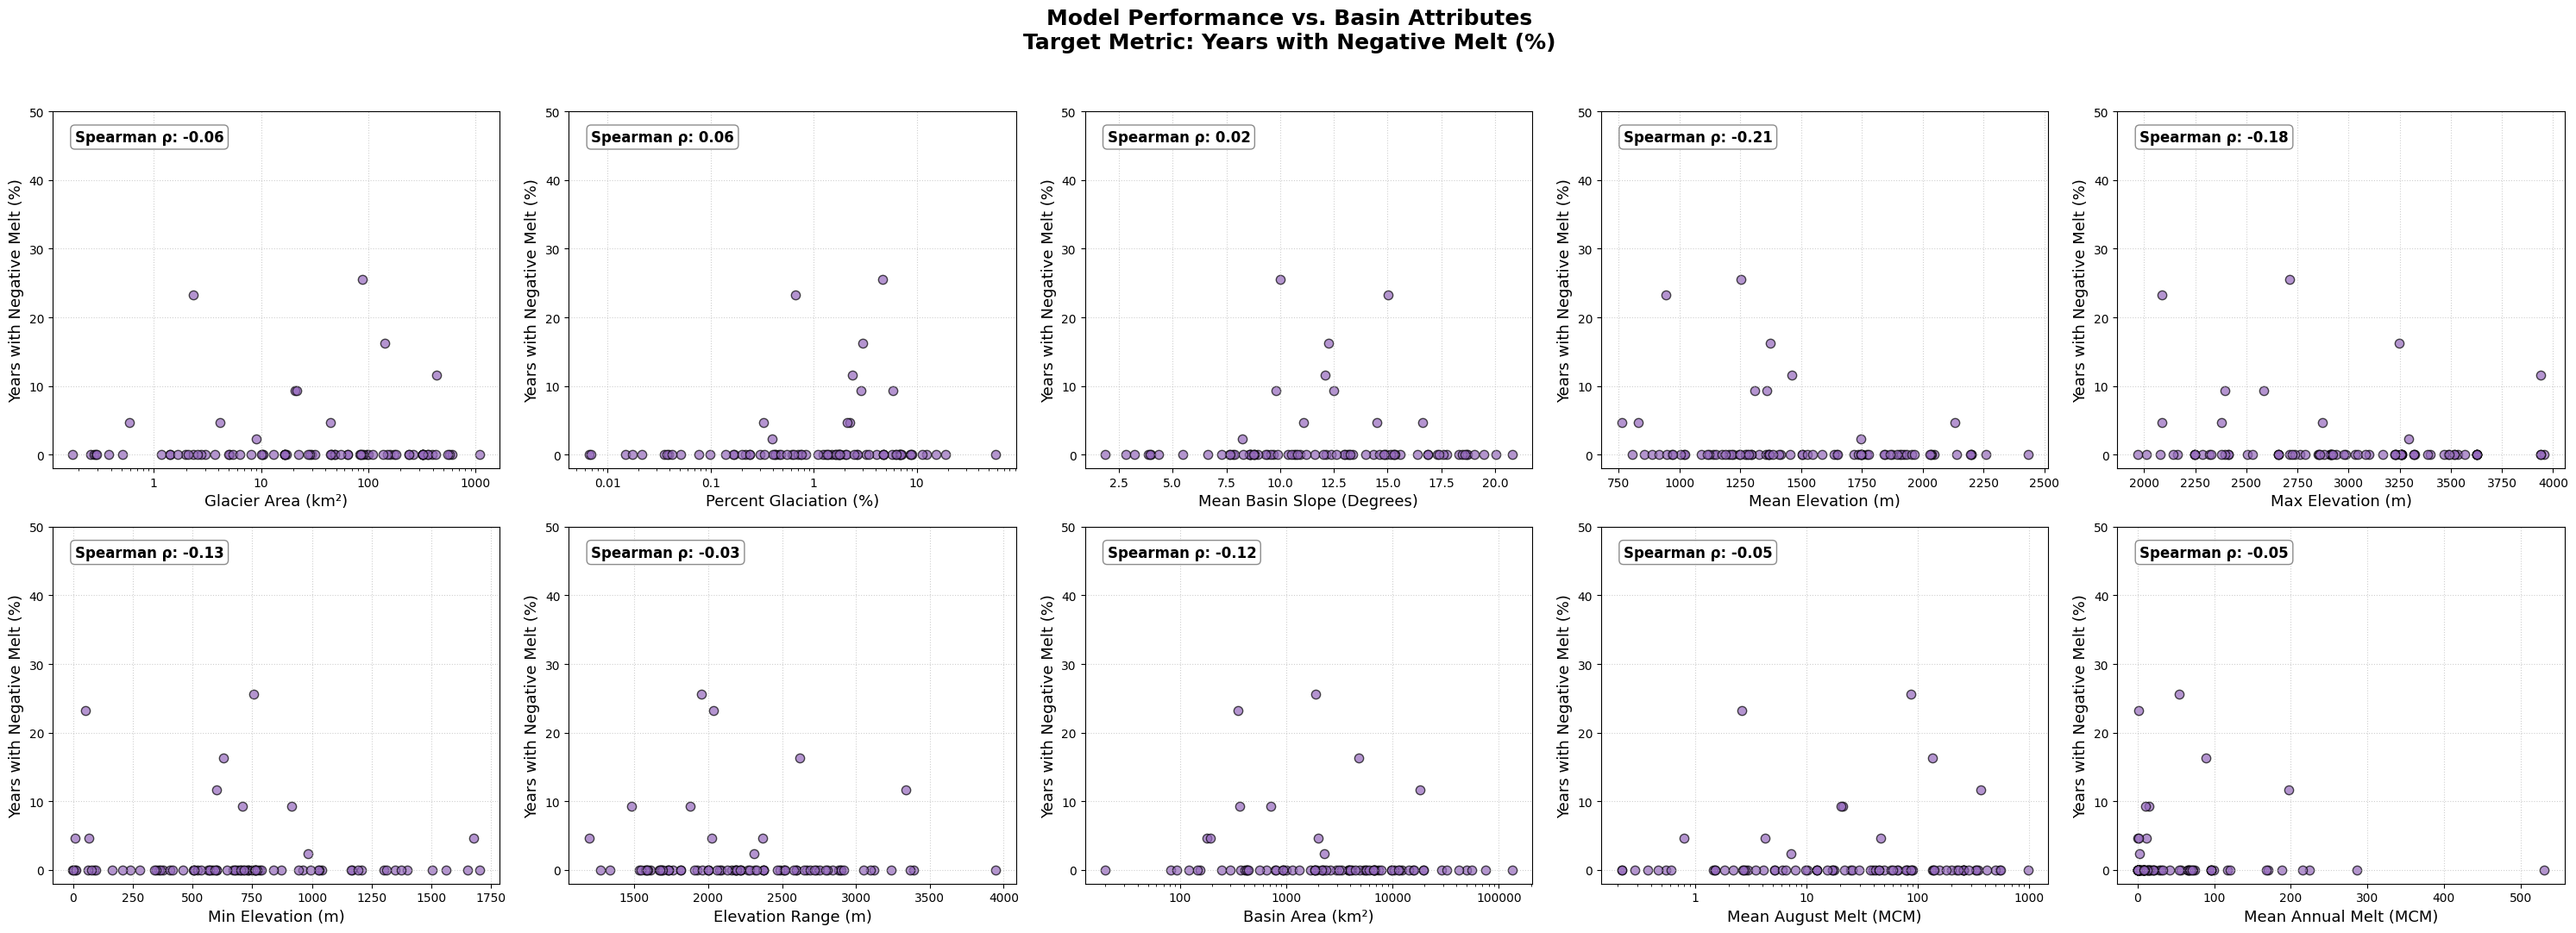

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Setup, Load Data, and Calculate Metrics
# =========================================================
print("Loading data and calculating metrics...")

# Load valid stations and attributes
with open(PROCESSED_DATA_DIR / "valid_glaciated_stations.txt", "r") as f:
    valid_stations = [line.strip() for line in f.readlines()]

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) 

common_stations = df_attr.index.intersection(df_mb.columns).intersection(valid_stations)

df_mb_full = df_mb[common_stations].copy()
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# Extract Actual August MCM (1980-2022)
df_act_mcm = df_mb_full[df_mb_full.index.month == 8].groupby(df_mb_full[df_mb_full.index.month == 8].index.year).sum()
df_act_mcm = df_act_mcm[(df_act_mcm.index >= 1980) & (df_act_mcm.index <= 2022)]

# Extract Actual Annual Mass Balance MCM (1980-2022) <-- NEW
df_ann_mcm = df_mb_full.groupby(df_mb_full.index.year).sum()
df_ann_mcm = df_ann_mcm[(df_ann_mcm.index >= 1980) & (df_ann_mcm.index <= 2022)]

# Extract Ensemble Predictions
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
ens_pred_mcm_list = []

for i in range(10):
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    
    diff_mm = pred - noglac
    diff_aug_mm = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
    
    pred_mcm = diff_aug_mm * basin_areas * 0.001
    pred_mcm = pred_mcm[(pred_mcm.index >= 1980) & (pred_mcm.index <= 2022)]
    ens_pred_mcm_list.append(pred_mcm)

df_pred_mean_mcm = sum(ens_pred_mcm_list) / 10
valid_mask = df_act_mcm.notna()
df_pred_mean_mcm = df_pred_mean_mcm.where(valid_mask)

# Calculate Station Metrics
metrics = []
for stat in common_stations:
    act = df_act_mcm[stat].dropna().values
    pred = df_pred_mean_mcm[stat].dropna().values
    
    # Calculate the mean ground truth volumes for this station <-- NEW
    mean_aug_mcm = df_act_mcm[stat].mean()
    mean_ann_mcm = df_ann_mcm[stat].mean()
    
    if len(act) > 2:
        r, _ = stats.pearsonr(act, pred)
        safe_mask = act > 0.01
        mdpe = np.median(((pred[safe_mask] - act[safe_mask]) / act[safe_mask]) * 100) if np.sum(safe_mask) > 0 else np.nan
        pct_neg = (np.sum(pred < 0) / len(pred)) * 100
        
        metrics.append({
            'Station': stat,
            'Pearson_r': r,
            'MdPE': mdpe,
            'Pct_Negative': pct_neg,
            'glacier_area_km2': df_attr.loc[stat, 'glacier_area_km2'],
            'glacier_pct': df_attr.loc[stat, 'glacier_pct'],
            'mean_slope': df_attr.loc[stat, 'mean_slope'],
            'mean_elev': df_attr.loc[stat, 'mean_elev'],
            'max_elev': df_attr.loc[stat, 'max_elev'],
            'min_elev': df_attr.loc[stat, 'min_elev'],
            'elev_range': df_attr.loc[stat, 'elev_range'],
            'basin_area_km2': df_attr.loc[stat, 'basin_area_km2'],
            'mean_aug_mcm': mean_aug_mcm,    # <-- NEW
            'mean_ann_mcm': mean_ann_mcm     # <-- NEW
        })

df_plot = pd.DataFrame(metrics).dropna(subset=['Pearson_r', 'MdPE'])

# =========================================================
# 2. Plotting Configuration
# =========================================================
print("Generating Plots...")

# Define the 10 attributes we want to plot against
attributes = [
    ('glacier_area_km2', 'Glacier Area (km²)', True),    
    ('glacier_pct', 'Percent Glaciation (%)', True),
    ('mean_slope', 'Mean Basin Slope (Degrees)', False),
    ('mean_elev', 'Mean Elevation (m)', False),
    ('max_elev', 'Max Elevation (m)', False),            
    ('min_elev', 'Min Elevation (m)', False),            
    ('elev_range', 'Elevation Range (m)', False),
    ('basin_area_km2', 'Basin Area (km²)', True),
    ('mean_aug_mcm', 'Mean August Melt (MCM)', True),    # <-- NEW
    ('mean_ann_mcm', 'Mean Annual Melt (MCM)', False)    # <-- NEW
]

# Define the 3 metrics we are evaluating
target_metrics = [
    ('Pearson_r', 'Pearson Correlation (r)', 'Linear Agreement (Higher is Better)', 'tab:blue', (0, 1.05)),
    ('MdPE', 'Median Percent Error (%)', 'Volume Error (Closer to 0 is Better)', 'tab:red', (-150, 150)),
    ('Pct_Negative', 'Years with Negative Melt (%)', 'Physical Plausibility (Lower is Better)', 'tab:purple', (-2, 50))
]

# =========================================================
# 3. Generate 3 Separate Figures
# =========================================================
for metric_col, metric_title, metric_desc, color, ylims in target_metrics:
    # Expanded grid to 2x5 and widened the figure to 30 inches to fit the new plots
    fig, axes = plt.subplots(2, 5, figsize=(30, 11))
    fig.suptitle(f'Model Performance vs. Basin Attributes\nTarget Metric: {metric_title}', fontsize=18, fontweight='bold', y=0.98)
    
    axes = axes.flatten()
    
    for ax, (attr_col, attr_name, use_log) in zip(axes, attributes):
        x = df_plot[attr_col]
        y = df_plot[metric_col]
        
        # Scatter Plot
        ax.scatter(x, y, color=color, alpha=0.7, edgecolor='k', s=55)
        
        # Calculate Spearman correlation to see if the attribute DRIVES the error
        rho, p_val = stats.spearmanr(x, y)
        sig_flag = "*" if p_val < 0.05 else "" 
        
        # Formatting
        ax.set_xlabel(attr_name, fontsize=13)
        ax.set_ylabel(metric_title, fontsize=13)
        ax.set_ylim(ylims)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        if use_log:
            ax.set_xscale('log')
            import matplotlib.ticker as ticker
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f"{val:g}"))
            
        # Add correlation text box
        text_str = f"Spearman ρ: {rho:.2f}{sig_flag}"
        props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12, 
                verticalalignment='top', bbox=props, fontweight='bold')
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Loading ground truth mass balance data...
Aggregating temporal subsets...
Generating plot...


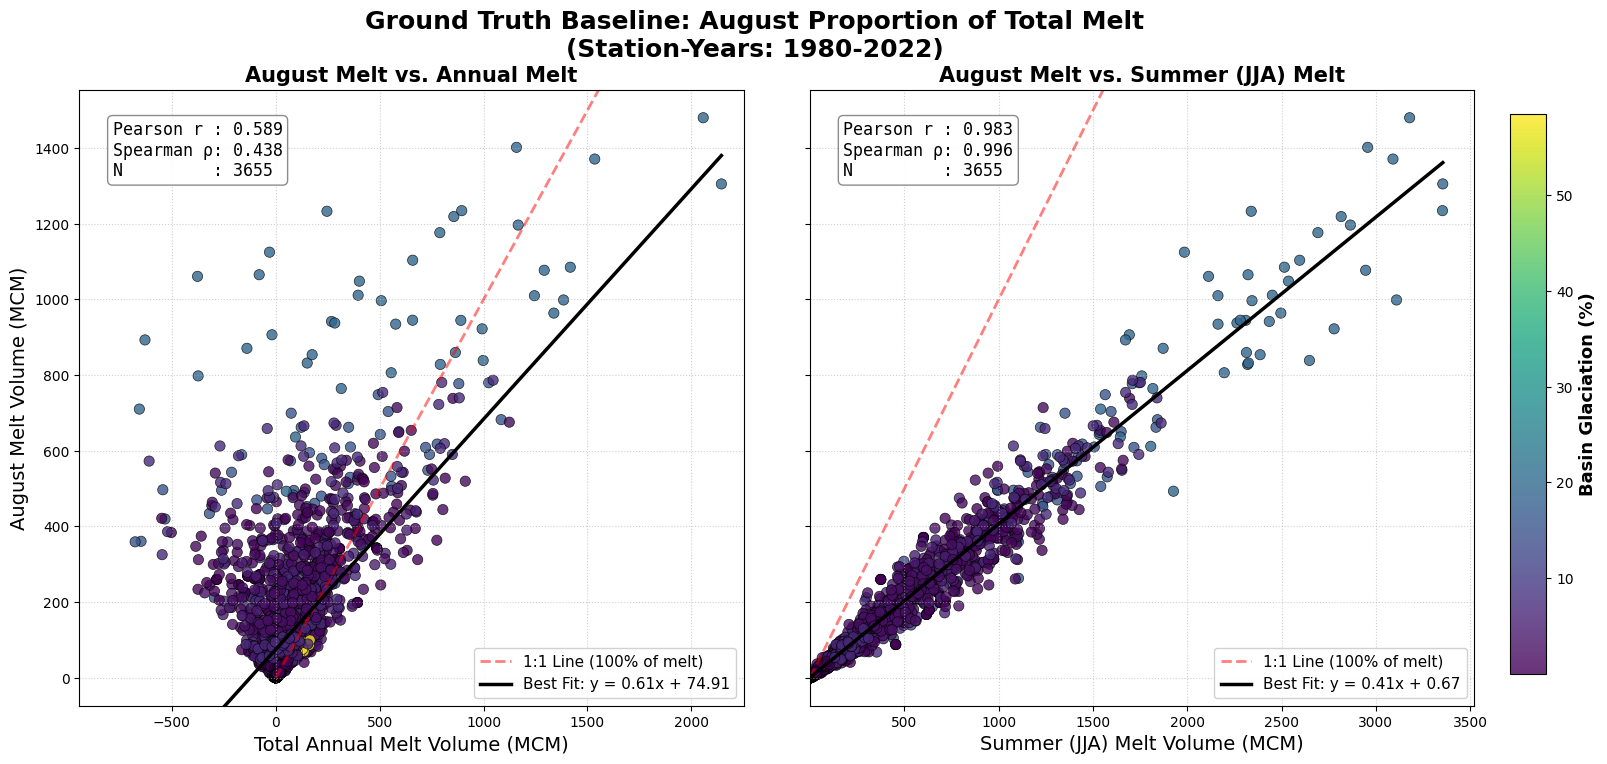

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
from src.config import PROCESSED_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Ground Truth Data
# =========================================================
print("Loading ground truth mass balance data...")

# Load valid stations
with open(PROCESSED_DATA_DIR / "valid_glaciated_stations.txt", "r") as f:
    valid_stations = [line.strip() for line in f.readlines()]

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)

# Negative values represent volume loss (melt), so we invert it to treat melt as positive
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True)

common_stations = df_attr.index.intersection(df_mb.columns).intersection(valid_stations)
df_mb_full = df_mb[common_stations]
glac_pct = df_attr.loc[common_stations, 'glacier_pct']

# =========================================================
# 2. Extract Temporal Subsets
# =========================================================
print("Aggregating temporal subsets...")

df_aug = df_mb_full[df_mb_full.index.month == 8].groupby(df_mb_full[df_mb_full.index.month == 8].index.year).sum()
df_jja = df_mb_full[df_mb_full.index.month.isin([6, 7, 8])].groupby(df_mb_full[df_mb_full.index.month.isin([6, 7, 8])].index.year).sum()
df_ann = df_mb_full.groupby(df_mb_full.index.year).sum()

# Limit to our study period
df_aug = df_aug[(df_aug.index >= 1980) & (df_aug.index <= 2022)]
df_jja = df_jja[(df_jja.index >= 1980) & (df_jja.index <= 2022)]
df_ann = df_ann[(df_ann.index >= 1980) & (df_ann.index <= 2022)]

# Helper function to align and flatten any two subsets
def align_and_flatten(df_y, df_x):
    y_vals, x_vals, glac_vals = [], [], []
    for stat in common_stations:
        y_stat = df_y[stat].dropna()
        x_stat = df_x[stat].dropna()
        
        common_years = y_stat.index.intersection(x_stat.index)
        
        y_vals.extend(y_stat.loc[common_years].values)
        x_vals.extend(x_stat.loc[common_years].values)
        glac_vals.extend([glac_pct[stat]] * len(common_years))
        
    return np.array(y_vals), np.array(x_vals), np.array(glac_vals)

# Extract for Plot 1 (Y=August, X=Annual)
aug_vals_1, ann_vals, glac_vals_1 = align_and_flatten(df_aug, df_ann)

# Extract for Plot 2 (Y=August, X=JJA)
aug_vals_2, jja_vals, glac_vals_2 = align_and_flatten(df_aug, df_jja)

# =========================================================
# 3. Calculate Correlation Metrics
# =========================================================
# Panel 1 Metrics (August vs Annual)
r_ann, _ = stats.pearsonr(ann_vals, aug_vals_1)
rho_ann, _ = stats.spearmanr(ann_vals, aug_vals_1)
m_ann, b_ann = np.polyfit(ann_vals, aug_vals_1, 1)

# Panel 2 Metrics (August vs JJA)
r_jja, _ = stats.pearsonr(jja_vals, aug_vals_2)
rho_jja, _ = stats.spearmanr(jja_vals, aug_vals_2)
m_jja, b_jja = np.polyfit(jja_vals, aug_vals_2, 1)

# =========================================================
# 4. Plotting
# =========================================================
print("Generating plot...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
fig.suptitle("Ground Truth Baseline: August Proportion of Total Melt\n(Station-Years: 1980-2022)", fontsize=18, fontweight='bold', y=0.98)

# Calculate global Y limits to keep both plots aligned
min_y = min(aug_vals_1.min(), aug_vals_2.min())
max_y = max(aug_vals_1.max(), aug_vals_2.max())

# --- PANEL 1: August vs Annual ---
sc1 = ax1.scatter(ann_vals, aug_vals_1, c=glac_vals_1, cmap='viridis', s=55, alpha=0.8, edgecolor='k', linewidth=0.5)

# 1:1 Line (If August accounted for 100% of the Annual Melt)
max_x_ann = ann_vals.max()
ax1.plot([min_y, max_x_ann], [min_y, max_x_ann], 'r--', alpha=0.5, linewidth=2, label='1:1 Line (100% of melt)')

x_line_ann = np.array([ann_vals.min(), max_x_ann])
ax1.plot(x_line_ann, m_ann*x_line_ann + b_ann, color='black', linewidth=2.5, label=f'Best Fit: y = {m_ann:.2f}x + {b_ann:.2f}')

ax1.set_title("August Melt vs. Annual Melt", fontsize=15, fontweight='bold')
ax1.set_xlabel("Total Annual Melt Volume (MCM)", fontsize=14)
ax1.set_ylabel("August Melt Volume (MCM)", fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right', fontsize=11, framealpha=0.9)

text_ann = (f"Pearson r : {r_ann:.3f}\n"
            f"Spearman ρ: {rho_ann:.3f}\n"
            f"N         : {len(aug_vals_1)}")
ax1.text(0.05, 0.95, text_ann, transform=ax1.transAxes, fontsize=12, family='monospace',
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# --- PANEL 2: August vs JJA ---
sc2 = ax2.scatter(jja_vals, aug_vals_2, c=glac_vals_2, cmap='viridis', s=55, alpha=0.8, edgecolor='k', linewidth=0.5)

# 1:1 Line (If August accounted for 100% of the Summer Melt)
max_x_jja = jja_vals.max()
ax2.plot([min_y, max_x_jja], [min_y, max_x_jja], 'r--', alpha=0.5, linewidth=2, label='1:1 Line (100% of melt)')

x_line_jja = np.array([jja_vals.min(), max_x_jja])
ax2.plot(x_line_jja, m_jja*x_line_jja + b_jja, color='black', linewidth=2.5, label=f'Best Fit: y = {m_jja:.2f}x + {b_jja:.2f}')

ax2.set_title("August Melt vs. Summer (JJA) Melt", fontsize=15, fontweight='bold')
ax2.set_xlabel("Summer (JJA) Melt Volume (MCM)", fontsize=14)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', fontsize=11, framealpha=0.9)

text_jja = (f"Pearson r : {r_jja:.3f}\n"
            f"Spearman ρ: {rho_jja:.3f}\n"
            f"N         : {len(aug_vals_2)}")
ax2.text(0.05, 0.95, text_jja, transform=ax2.transAxes, fontsize=12, family='monospace',
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# Axis limit cleanups
ax1.set_xlim(ann_vals.min() * 0.9, max_x_ann * 1.05)
ax2.set_xlim(jja_vals.min() * 0.9, max_x_jja * 1.05)
ax1.set_ylim(min_y - (max_y*0.05), max_y * 1.05)

# Shared Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc1, cax=cbar_ax)
cbar.set_label("Basin Glaciation (%)", fontsize=13, fontweight='bold')

plt.subplots_adjust(right=0.9, wspace=0.1)
plt.show()

Troubleshooting zero glacier melt basins

In [16]:
import geopandas as gpd
import pandas as pd
import warnings
from src.config import DRAINAGE_FILES, GLACIER_SHP_PATH, MASS_BALANCE_PATH, PROCESSED_DATA_DIR

CANADA_ALBERS_CRS = "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs"

print("⏳ Loading data...")

# 1. Get the exact subset of stations
df_flow = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col="Date", parse_dates=True)
stations = df_flow.columns.tolist()
# Ensure they are strings to match the shapefile IDs
requested_stations = set([str(s).strip() for s in stations]) 

# 2. Load Mass Balance Data
mb_df = pd.read_csv(MASS_BALANCE_PATH, index_col=0)
known_glaciers = set(mb_df.index)

# 3. Load and Filter Basins
print("⏳ Loading and filtering basins...")
basins_list = []
for path in DRAINAGE_FILES:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        gdf = gpd.read_file(path, layer='DrainageBasin_BassinDeDrainage')
        id_col = next((c for c in gdf.columns if c.lower() in ['stationnum', 'id', 'station_id']), None)
        if id_col:
            gdf = gdf[[id_col, 'geometry']].rename(columns={id_col: 'station_id'})
            basins_list.append(gdf)

gdf_basins = pd.concat(basins_list, ignore_index=True)
gdf_basins['station_id'] = gdf_basins['station_id'].astype(str).str.strip()

# FILTER BASINS HERE to drastically reduce workload before any spatial math
gdf_basins = gdf_basins[gdf_basins['station_id'].isin(requested_stations)].copy()
gdf_basins = gdf_basins.to_crs(CANADA_ALBERS_CRS)
print(f"✅ Filtered down to {len(gdf_basins)} active basins.")

# 4. Load Glaciers and Convert to Points (The massive speedup!)
print("⏳ Loading glaciers and converting to centroids...")
gdf_glaciers = gpd.read_file(GLACIER_SHP_PATH)
rgi_col = next((c for c in gdf_glaciers.columns if 'rgiid' in c.lower()), 'RGIId')
gdf_glaciers = gdf_glaciers.rename(columns={rgi_col: 'RGIId'})
gdf_glaciers = gdf_glaciers.to_crs(CANADA_ALBERS_CRS)

# Pre-calculate the exact area in km2 BEFORE changing the shapes to points
gdf_glaciers['exact_area_km2'] = gdf_glaciers.geometry.area / 1e6

# Convert polygons to centroids (points)
gdf_glaciers['geometry'] = gdf_glaciers.geometry.centroid

# 5. Fast Point-in-Polygon Spatial Join
print("⏳ Performing Point-in-Polygon spatial join...")
# This instantly checks which basin polygon contains which glacier center-point
joined = gpd.sjoin(
    gdf_glaciers[['RGIId', 'exact_area_km2', 'geometry']],
    gdf_basins[['station_id', 'geometry']],
    how='inner',
    predicate='within' 
)

# 6. Diagnostics & Missing RGI Extraction
print("🔍 Analyzing missing data...")
joined['has_mb_data'] = joined['RGIId'].isin(known_glaciers)

total_glacier_area = joined.groupby('station_id')['exact_area_km2'].sum()
valid_glacier_area = joined[joined['has_mb_data']].groupby('station_id')['exact_area_km2'].sum()

diag_df = pd.DataFrame({
    'Total_Glacier_Area_km2': total_glacier_area,
    'Valid_MB_Area_km2': valid_glacier_area
}).fillna(0)

diag_df['Missing_Area_km2'] = diag_df['Total_Glacier_Area_km2'] - diag_df['Valid_MB_Area_km2']
diag_df['Pct_Area_Missing'] = (diag_df['Missing_Area_km2'] / diag_df['Total_Glacier_Area_km2']) * 100

# --- NEW: Extracting the missing RGI IDs ---
# Filter for glaciers that dropped out of the mass balance dataset
missing_glaciers = joined[~joined['has_mb_data']]

# Group the missing RGI IDs by basin and map them back to the main dataframe
missing_rgis_per_basin = missing_glaciers.groupby('station_id')['RGIId'].apply(lambda x: list(x.unique()))

# Use a lambda to ensure basins with 0 missing glaciers get an empty list instead of NaN
diag_df['Missing_RGI_IDs'] = diag_df.index.map(missing_rgis_per_basin).map(lambda x: x if isinstance(x, list) else [])

# Sort to find the worst offenders
problem_basins = diag_df[diag_df['Missing_Area_km2'] > 0].sort_values('Pct_Area_Missing', ascending=False)

print(f"\n🚨 Found {len(problem_basins)} basins with missing mass balance data!")
print(f"🧊 Total unique missing glaciers across all basins: {missing_glaciers['RGIId'].nunique()}")
print("-" * 60)

# Display the high-level overview (excluding the massive ID lists for readability)
display(problem_basins[['Total_Glacier_Area_km2', 'Missing_Area_km2', 'Pct_Area_Missing']].head(20).round(2))

# Print the exact IDs for the top 5 worst basins
print("\n--- Exact Missing RGIs for Top 5 Worst Basins ---")
for basin_id in problem_basins.head(5).index:
    rgis = problem_basins.loc[basin_id, 'Missing_RGI_IDs']
    
    # Cap the printout at 10 IDs per basin so it doesn't flood your notebook
    display_rgis = rgis[:10] 
    suffix = "..." if len(rgis) > 10 else ""
    
    print(f"Basin {basin_id} ({len(rgis)} missing glaciers):")
    print(f"  {', '.join(display_rgis)}{suffix}\n")

⏳ Loading data...
⏳ Loading and filtering basins...
✅ Filtered down to 269 active basins.
⏳ Loading glaciers and converting to centroids...
⏳ Performing Point-in-Polygon spatial join...
🔍 Analyzing missing data...

🚨 Found 8 basins with missing mass balance data!
🧊 Total unique missing glaciers across all basins: 147
------------------------------------------------------------


,Total_Glacier_Area_km2,Missing_Area_km2,Pct_Area_Missing
station_id,,,
08MH016,7.78,7.78,100.00
08MH056,1.97,1.97,100.00
08MH103,8.37,8.37,100.00
08NL007,0.41,0.41,100.00
08NL069,0.25,0.25,100.00
08NL038,0.41,0.41,100.00
08NL070,0.16,0.16,100.00
05AD003,3.43,3.33,97.07



--- Exact Missing RGIs for Top 5 Worst Basins ---
Basin 08MH016 (53 missing glaciers):
  RGI60-02.17494, RGI60-02.17498, RGI60-02.17501, RGI60-02.17505, RGI60-02.17506, RGI60-02.17508, RGI60-02.17509, RGI60-02.17510, RGI60-02.17511, RGI60-02.17515...

Basin 08MH056 (22 missing glaciers):
  RGI60-02.17444, RGI60-02.17537, RGI60-02.17550, RGI60-02.17625, RGI60-02.17626, RGI60-02.17629, RGI60-02.17630, RGI60-02.17631, RGI60-02.17632, RGI60-02.17633...

Basin 08MH103 (67 missing glaciers):
  RGI60-02.17443, RGI60-02.17494, RGI60-02.17498, RGI60-02.17501, RGI60-02.17505, RGI60-02.17506, RGI60-02.17508, RGI60-02.17509, RGI60-02.17510, RGI60-02.17511...

Basin 08NL007 (13 missing glaciers):
  RGI60-02.17446, RGI60-02.17665, RGI60-02.17666, RGI60-02.17667, RGI60-02.17668, RGI60-02.17705, RGI60-02.17711, RGI60-02.17712, RGI60-02.17713, RGI60-02.17714...

Basin 08NL069 (8 missing glaciers):
  RGI60-02.17705, RGI60-02.17711, RGI60-02.17712, RGI60-02.17713, RGI60-02.17714, RGI60-02.17715, RGI60-0

In [17]:
# =========================================================
# SAVE VALID STATIONS TO FILE
# =========================================================
# Filter for basins that actually have glaciers, but 0 missing area
valid_glaciated_df = diag_df[(diag_df['Total_Glacier_Area_km2'] > 0) & (diag_df['Missing_Area_km2'] == 0)]
valid_stations = valid_glaciated_df.index.tolist()

# Save as a simple text list
output_file = PROCESSED_DATA_DIR / "valid_glaciated_stations.txt"
with open(output_file, 'w') as f:
    for stat in valid_stations:
        f.write(f"{stat}\n")

print(f"\n✅ Saved {len(valid_stations)} fully valid glaciated stations to {output_file.name}")


✅ Saved 85 fully valid glaciated stations to valid_glaciated_stations.txt


🗺️ Generating diagnostic map in Lat/Lon...


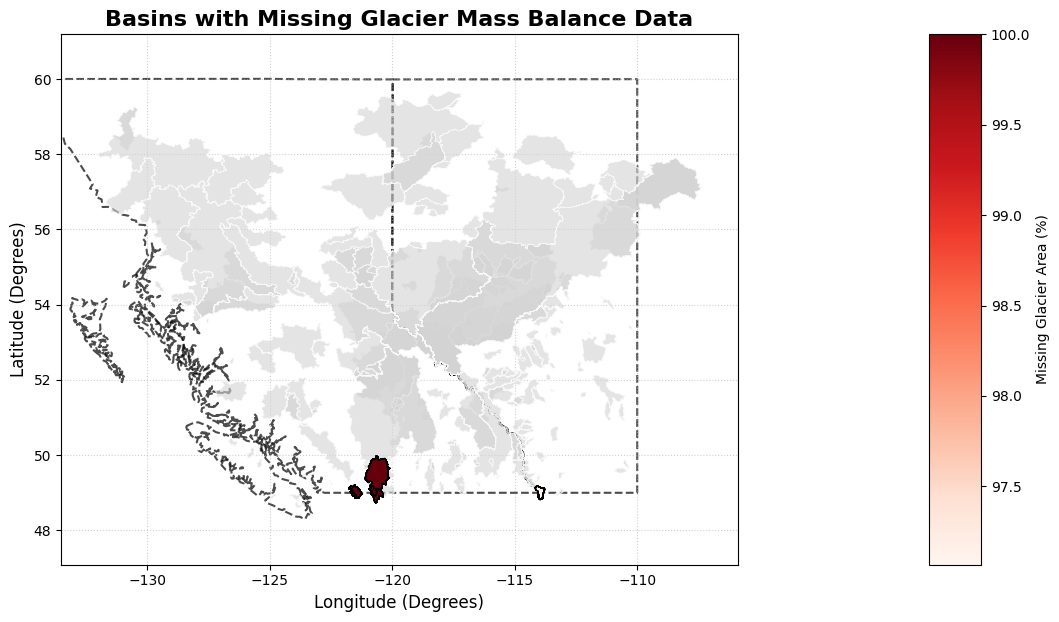

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import geopandas as gpd

print("🗺️ Generating diagnostic map in Lat/Lon...")

# 1. Fetch Province Boundaries (BC and Alberta)
# We pull a lightweight, standard GeoJSON of Canada directly from the web
try:
    url_provinces = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/canada.geojson"
    canada = gpd.read_file(url_provinces)
    bc_ab = canada[canada['name'].isin(['British Columbia', 'Alberta'])]
    bc_ab = bc_ab.to_crs("EPSG:4326") # Ensure it is in degrees
except Exception as e:
    print(f"⚠️ Could not load province boundaries from web: {e}")
    bc_ab = None

# 2. Prepare the basin geometries
problem_geoms = gdf_basins[gdf_basins['station_id'].isin(problem_basins.index)].copy()
problem_geoms = problem_geoms.merge(
    problem_basins[['Pct_Area_Missing']], 
    left_on='station_id', 
    right_index=True
)

# REPROJECT to EPSG:4326 (WGS 84) to convert Easting/Northing into Lat/Lon Degrees
gdf_basins_wgs = gdf_basins.to_crs("EPSG:4326")
problem_geoms_wgs = problem_geoms.to_crs("EPSG:4326")

# 3. Setup the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot Provinces (Background Context)
if bc_ab is not None:
    bc_ab.plot(
        ax=ax,
        facecolor='none',       # Transparent fill so we can see the grid
        edgecolor='black',      # Dark border
        linewidth=1.5,
        linestyle='--',
        alpha=0.7,
        zorder=1
    )

# Plot ALL active basins as a background context (Light Gray)
gdf_basins_wgs.plot(
    ax=ax, 
    facecolor='lightgray', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.6,
    zorder=2
)

# 4. Plot the Problematic Basins on top, colored by severity (Reds)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

problem_geoms_wgs.plot(
    ax=ax,
    column='Pct_Area_Missing',
    cmap='Reds',
    edgecolor='black',
    linewidth=0.8,
    legend=True,
    cax=cax,
    zorder=3,
    legend_kwds={'label': 'Missing Glacier Area (%)'}
)

# 5. Formatting
ax.set_title("Basins with Missing Glacier Mass Balance Data", fontsize=16, fontweight='bold')
ax.set_xlabel("Longitude (Degrees)", fontsize=12)
ax.set_ylabel("Latitude (Degrees)", fontsize=12)

# Smart Zoom: BC and AB go very far north. To prevent the map from zooming out 
# too far, we lock the camera to the boundaries of your actual basins + a 1 degree buffer.
minx, miny, maxx, maxy = gdf_basins_wgs.total_bounds
ax.set_xlim(minx - 1.5, maxx + 1.5)
ax.set_ylim(miny - 1.5, maxy + 1.5)

# Add gridlines for readability
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Stations that don't have any ground truth melt data are those that have headwaters in the US. These are fine to keep in the streamflow testing pool but should be removed from the glacier correlation dataset.

--- AVAILABLE GLACIATED STATIONS ---
[00] Station: 05AD003
[01] Station: 05BA001
[02] Station: 05BB001
[03] Station: 05CA004
[04] Station: 05CA009
[05] Station: 05DA007
[06] Station: 05DA009
[07] Station: 05DA010
[08] Station: 05DB006
[09] Station: 07AA001
[10] Station: 07AA002
[11] Station: 07AD002
[12] Station: 07AE001
[13] Station: 07BE001
[14] Station: 07DA001
[15] Station: 07EA004
[16] Station: 07EA005
[17] Station: 07EC002
[18] Station: 07EC003
[19] Station: 07EE007
[20] Station: 07FB001
[21] Station: 07FB002
[22] Station: 07FB003
[23] Station: 07FB006
[24] Station: 07GA001
[25] Station: 07GJ001
[26] Station: 08CE001
[27] Station: 08DB001
[28] Station: 08EB004
[29] Station: 08EC013
[30] Station: 08ED001
[31] Station: 08ED002
[32] Station: 08EE004
[33] Station: 08EE008
[34] Station: 08EE020
[35] Station: 08EF001
[36] Station: 08EF005
[37] Station: 08EG012
[38] Station: 08FA002
[39] Station: 08FB004
[40] Station: 08FE003
[41] Station: 08FF001
[42] Station: 08FF002
[43] Station: 08F

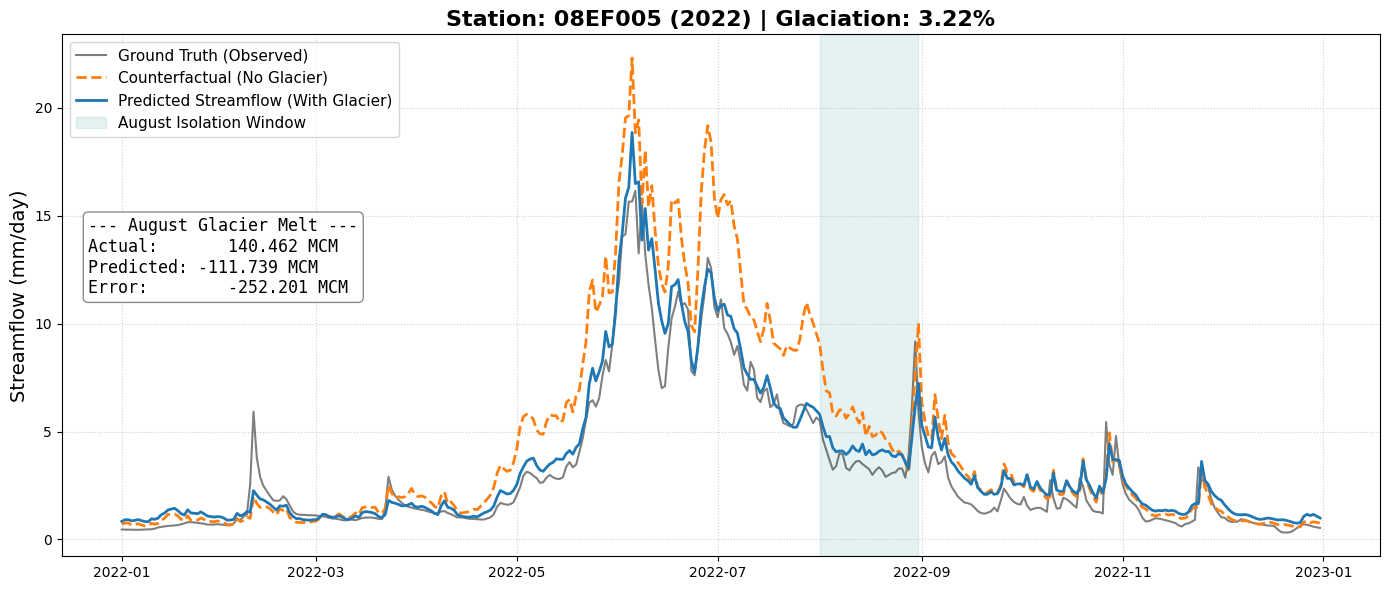

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Initial Setup & Print Station List
# =========================================================
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) 

# Get template for test dates/stations
df_test_template = pd.read_csv(OUTPUT_DATA_DIR / "test_set_predictions.csv", index_col=0, parse_dates=True)
test_dates = df_test_template.index

glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index
common_stations = glaciated_stations.intersection(df_test_template.columns).intersection(df_mb.columns)
stations_list = common_stations.tolist()

print("--- AVAILABLE GLACIATED STATIONS ---")
for i, stat in enumerate(stations_list):
    print(f"[{i:02d}] Station: {stat}")
print("-" * 36)

# =========================================================
# 2. User Input (Prompts will appear below the cell)
# =========================================================
try:
    stat_idx = int(input("Enter the Index number of the station you want to plot: "))
    target_year = int(input(f"Enter the Year (e.g., 2013 - 2022): "))
    
    target_station = stations_list[stat_idx]
except (ValueError, IndexError):
    print("\n[!] Invalid input. Please run the cell again and enter valid numbers.")
    raise

print(f"\nLoading data for Station {target_station} in {target_year}...")

# =========================================================
# 3. Load ONLY the specific station from the Ensemble
# =========================================================
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
list_pred_series, list_noglac_series = [], []

for i in range(10):
    # Only pull the exact column we need from the CSV to save memory and time
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[target_station]
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[target_station]
    
    list_pred_series.append(pred.loc[test_dates])
    list_noglac_series.append(noglac.loc[test_dates])

# Calculate Ensemble Means for this one station
pred_series = sum(list_pred_series) / 10
noglac_series = sum(list_noglac_series) / 10

# Load Ground Truth
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
obs_series = df_obs.loc[test_dates, target_station].copy()

# Convert Obs to mm/day
basin_area = df_attr.loc[target_station, 'basin_area_km2']
obs_series = obs_series * (86.4 / basin_area)

# =========================================================
# 4. Calculate August Volumes & Plot
# =========================================================
# Slice the timeseries for the selected year
obs_year = obs_series.loc[str(target_year)]
pred_year = pred_series.loc[str(target_year)]
noglac_year = noglac_series.loc[str(target_year)]

# Calculate August Melt Volumes (MCM)
aug_pred = pred_year[pred_year.index.month == 8].sum()
aug_noglac = noglac_year[noglac_year.index.month == 8].sum()

pred_melt_mcm = (aug_pred - aug_noglac) * basin_area * 0.001
act_melt_mcm = df_mb.loc[f"{target_year}-08", target_station].sum()

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(obs_year.index, obs_year.values, color='black', alpha=0.5, label='Ground Truth (Observed)', linewidth=1.5)
ax.plot(noglac_year.index, noglac_year.values, color='tab:orange', linestyle='--', label='Counterfactual (No Glacier)', linewidth=2)
ax.plot(pred_year.index, pred_year.values, color='tab:blue', label='Predicted Streamflow (With Glacier)', linewidth=2)

# Highlight August
august_start = pd.to_datetime(f"{target_year}-08-01")
august_end = pd.to_datetime(f"{target_year}-08-31")
ax.axvspan(august_start, august_end, color='teal', alpha=0.1, label='August Isolation Window')

# Formatting
glac_pct = df_attr.loc[target_station, 'glacier_pct']
ax.set_title(f"Station: {target_station} ({target_year}) | Glaciation: {glac_pct:.2f}%", fontsize=16, fontweight='bold')
ax.set_ylabel("Streamflow (mm/day)", fontsize=14)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)

# Text Box with August Volumes
text_str = (
    f"--- August Glacier Melt ---\n"
    f"Actual:       {act_melt_mcm:>7.3f} MCM\n"
    f"Predicted: {pred_melt_mcm:>7.3f} MCM\n"
    f"Error:        {(pred_melt_mcm - act_melt_mcm):>7.3f} MCM"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.02, 0.65, text_str, transform=ax.transAxes, fontsize=12, family='monospace',
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

Loading data and filtering for valid stations...
Calculating Pearson correlations for all 10 ensemble members...
Aggregating uncertainty bounds...


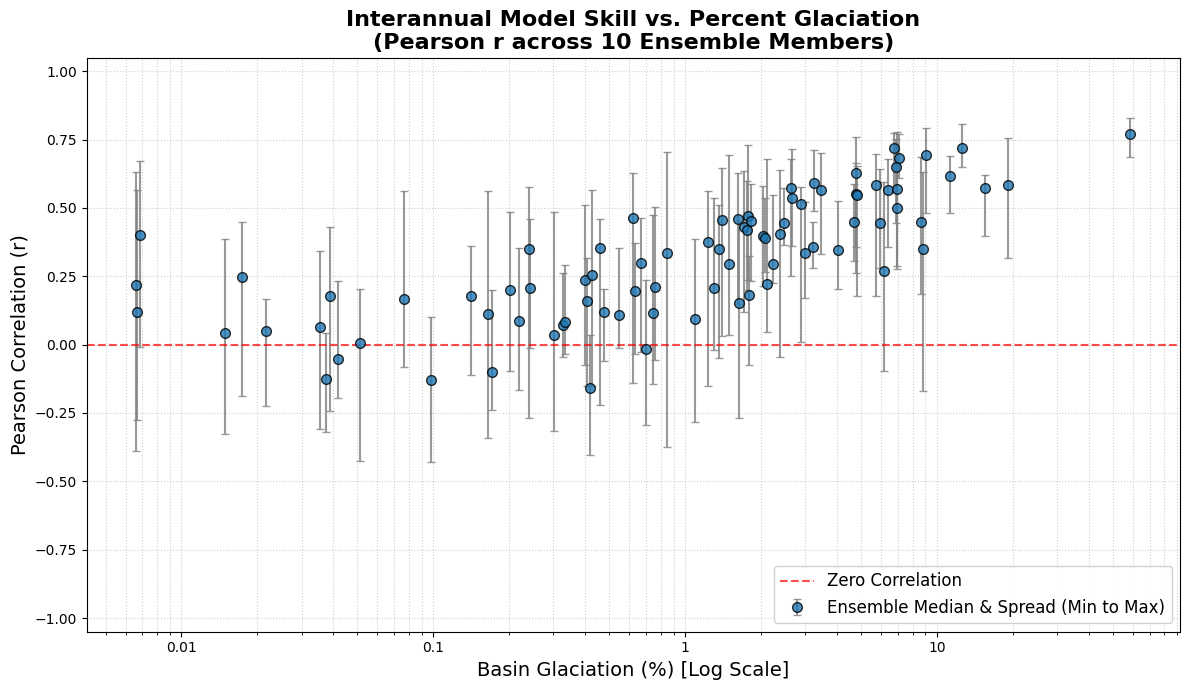

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Valid Stations & Static Data
# =========================================================
print("Loading data and filtering for valid stations...")

# Load the verified stations you saved from the spatial script
with open(PROCESSED_DATA_DIR / "valid_glaciated_stations.txt", "r") as f:
    valid_stations = [line.strip() for line in f.readlines()]

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) # Native MCM

# Ensure we only use valid stations that also have attributes and MB data
common_stations = df_attr.index.intersection(df_mb.columns).intersection(valid_stations)

df_mb_full = df_mb[common_stations].copy()
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']
glac_pct = df_attr.loc[common_stations, 'glacier_pct']

# Calculate Actual August MCM per year (1980-2022)
df_act_mcm = df_mb_full[df_mb_full.index.month == 8].groupby(df_mb_full[df_mb_full.index.month == 8].index.year).sum()
df_act_mcm = df_act_mcm[(df_act_mcm.index >= 1980) & (df_act_mcm.index <= 2022)]

# =========================================================
# 2. Calculate Pearson Correlation Per Ensemble Member
# =========================================================
print("Calculating Pearson correlations for all 10 ensemble members...")
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"

# Dictionary to hold the 10 correlation scores for each station
station_corrs = {stat: [] for stat in common_stations}

for i in range(10):
    # Load specific member predictions
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    
    # Calculate August Predicted MCM for this specific member
    diff_mm = pred - noglac
    diff_aug_mm = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
    pred_mcm = diff_aug_mm * basin_areas * 0.001
    pred_mcm = pred_mcm[(pred_mcm.index >= 1980) & (pred_mcm.index <= 2022)]
    
    # Align years perfectly with actual data
    common_years = df_act_mcm.index.intersection(pred_mcm.index)
    act_aligned = df_act_mcm.loc[common_years]
    pred_aligned = pred_mcm.loc[common_years]
    
    # Calculate Pearson Correlation for each station over the 42 years
    for stat in common_stations:
        act_series = act_aligned[stat].values
        pred_series = pred_aligned[stat].values
        
        # Only calculate if there is actual variance to avoid flatline math errors
        if np.std(act_series) > 0.0001 and np.std(pred_series) > 0.0001:
            r, _ = stats.pearsonr(act_series, pred_series)
            station_corrs[stat].append(r)
        else:
            station_corrs[stat].append(np.nan)

# =========================================================
# 3. Aggregate Ensemble Uncertainty
# =========================================================
print("Aggregating uncertainty bounds...")

# Calculate Median, Min, and Max correlation for error bars
records = []
for stat, corrs in station_corrs.items():
    if len(corrs) > 0 and not np.all(np.isnan(corrs)):
        med_r = np.nanmedian(corrs)
        min_r = np.nanmin(corrs)
        max_r = np.nanmax(corrs)
        records.append({
            'Station': stat,
            'Glacier_Pct': glac_pct[stat],
            'Median_R': med_r,
            'Error_Lower': med_r - min_r, # Distance from median to min
            'Error_Upper': max_r - med_r  # Distance from median to max
        })

df_plot = pd.DataFrame(records).sort_values(by='Glacier_Pct')

# =========================================================
# 4. Plotting Scatter with Error Bars
# =========================================================
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the individual station dots with Ensemble Error Bars
ax.errorbar(df_plot['Glacier_Pct'], df_plot['Median_R'], 
            yerr=[df_plot['Error_Lower'], df_plot['Error_Upper']], 
            fmt='o', color='tab:blue', ecolor='gray', elinewidth=1.5, capsize=3, alpha=0.8,
            markeredgecolor='black', markersize=7, label='Ensemble Median & Spread (Min to Max)')

# Formatting
ax.axhline(0, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Zero Correlation')
ax.set_title('Interannual Model Skill vs. Percent Glaciation\n(Pearson r across 10 Ensemble Members)', fontsize=16, fontweight='bold')
ax.set_xlabel('Basin Glaciation (%) [Log Scale]', fontsize=14)
ax.set_ylabel("Pearson Correlation (r)", fontsize=14)

# Set X-axis to Log Scale to prevent clustering on the left edge
ax.set_xscale('log')

# Custom X-ticks so the log scale is readable
import matplotlib.ticker as ticker
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

# Add a subtle grid
ax.grid(True, linestyle=':', alpha=0.6, which='both')
ax.set_ylim(-1.05, 1.05)
ax.legend(loc='lower right', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

Loading data and filtering for valid stations...
Calculating ensemble mean predictions (1980-2022)...
Flattening dataset and computing metrics...


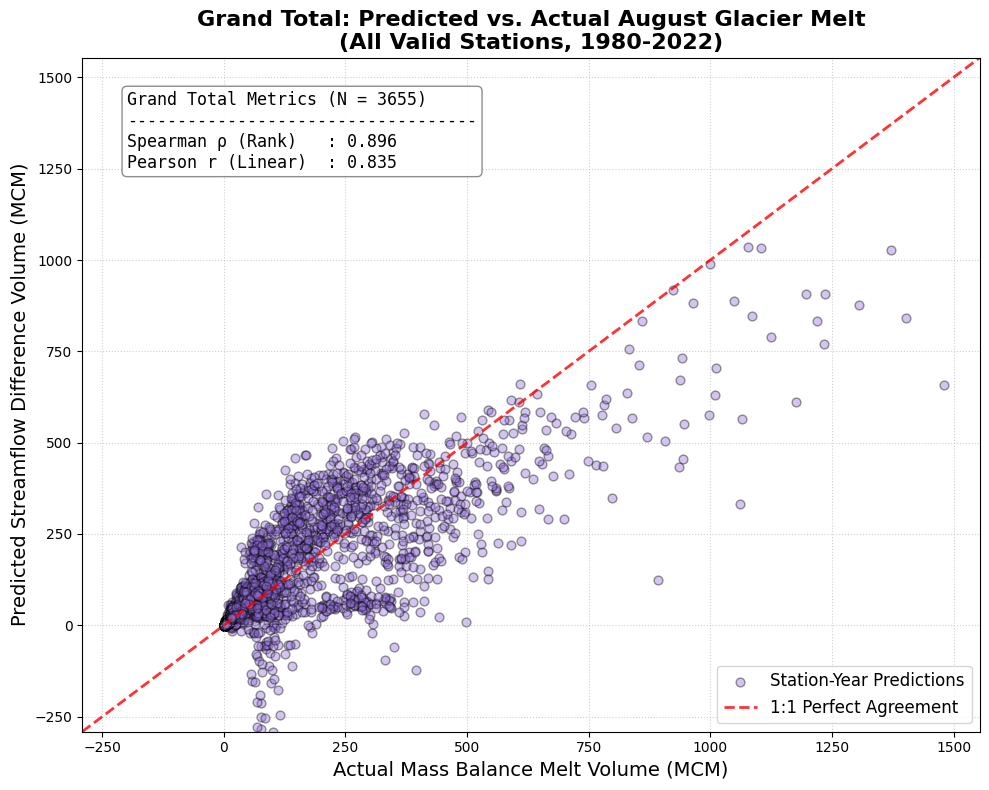

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Valid Stations & Static Data
# =========================================================
print("Loading data and filtering for valid stations...")

# Load the verified stations saved from the spatial script
with open(PROCESSED_DATA_DIR / "valid_glaciated_stations.txt", "r") as f:
    valid_stations = [line.strip() for line in f.readlines()]

df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) # Native MCM

common_stations = df_attr.index.intersection(df_mb.columns).intersection(valid_stations)

df_mb_full = df_mb[common_stations].copy()
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# Calculate Actual August MCM per year (1980-2022)
df_act_mcm = df_mb_full[df_mb_full.index.month == 8].groupby(df_mb_full[df_mb_full.index.month == 8].index.year).sum()
df_act_mcm = df_act_mcm[(df_act_mcm.index >= 1980) & (df_act_mcm.index <= 2022)]

# =========================================================
# 2. Calculate Ensemble Mean Predictions
# =========================================================
print("Calculating ensemble mean predictions (1980-2022)...")
ensemble_dir = OUTPUT_DATA_DIR / "phase_split"

# Get full date index from a template
template = pd.read_csv(ensemble_dir / "phase-split_preds_member_0.csv", index_col=0, parse_dates=True)
full_dates = template.index

df_pred_sum = pd.DataFrame(0.0, index=full_dates, columns=common_stations)
df_noglac_sum = pd.DataFrame(0.0, index=full_dates, columns=common_stations)

for i in range(10):
    pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    df_pred_sum += pred
    df_noglac_sum += noglac

df_pred_mean = df_pred_sum / 10
df_noglac_mean = df_noglac_sum / 10

# Calculate daily difference (mm/day)
df_diff_mm = df_pred_mean - df_noglac_mean

# Isolate August and calculate monthly sum (mm/month)
df_diff_aug_mm = df_diff_mm[df_diff_mm.index.month == 8].groupby(df_diff_mm[df_diff_mm.index.month == 8].index.year).sum()

# Convert predicted depth to volume (MCM)
df_pred_mcm = df_diff_aug_mm * basin_areas * 0.001
df_pred_mcm = df_pred_mcm[(df_pred_mcm.index >= 1980) & (df_pred_mcm.index <= 2022)]

# =========================================================
# 3. Flatten Data and Calculate Grand Total Correlation
# =========================================================
print("Flattening dataset and computing metrics...")

# Align years perfectly
common_years = df_act_mcm.index.intersection(df_pred_mcm.index)
act_aligned = df_act_mcm.loc[common_years].values.flatten()
pred_aligned = df_pred_mcm.loc[common_years].values.flatten()

# Remove NaNs to compute clean correlations
valid_mask = ~(np.isnan(act_aligned) | np.isnan(pred_aligned))
act_clean = act_aligned[valid_mask]
pred_clean = pred_aligned[valid_mask]

# Calculate Metrics
pearson_r, _ = stats.pearsonr(act_clean, pred_clean)
spearman_rho, _ = stats.spearmanr(act_clean, pred_clean)

# =========================================================
# 4. Plotting
# =========================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter Plot
ax.scatter(act_clean, pred_clean, color='mediumpurple', alpha=0.4, edgecolor='k', s=40, label='Station-Year Predictions')

# 1:1 Reference Line
max_val = max(act_clean.max(), pred_clean.max())
min_val = min(min(act_clean), min(pred_clean), 0) # Account for any negative predictions
ax.plot([min_val, max_val * 1.05], [min_val, max_val * 1.05], 'r--', linewidth=2, alpha=0.8, label='1:1 Perfect Agreement')

# Formatting
ax.set_title('Grand Total: Predicted vs. Actual August Glacier Melt\n(All Valid Stations, 1980-2022)', fontsize=16, fontweight='bold')
ax.set_xlabel('Actual Mass Balance Melt Volume (MCM)', fontsize=14)
ax.set_ylabel('Predicted Streamflow Difference Volume (MCM)', fontsize=14)

# Set axes limits to start neatly at the minimum value
ax.set_xlim(min_val, max_val * 1.05)
ax.set_ylim(min_val, max_val * 1.05)

# Text Box with Metrics
text_str = (
    f"Grand Total Metrics (N = {len(act_clean)})\n"
    f"-----------------------------------\n"
    f"Spearman ρ (Rank)   : {spearman_rho:.3f}\n"
    f"Pearson r (Linear)  : {pearson_r:.3f}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12, family='monospace',
        verticalalignment='top', bbox=props)

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

Loading static attributes and mass balance...
Calculating ensemble means over the entire dataset (this may take a moment)...
Scanning for negative predicted glacier melt anomalies...

[!] Found 182 occurrences of negative predicted glacier melt.
Generating plots for the Top 10 most extreme negative occurrences...



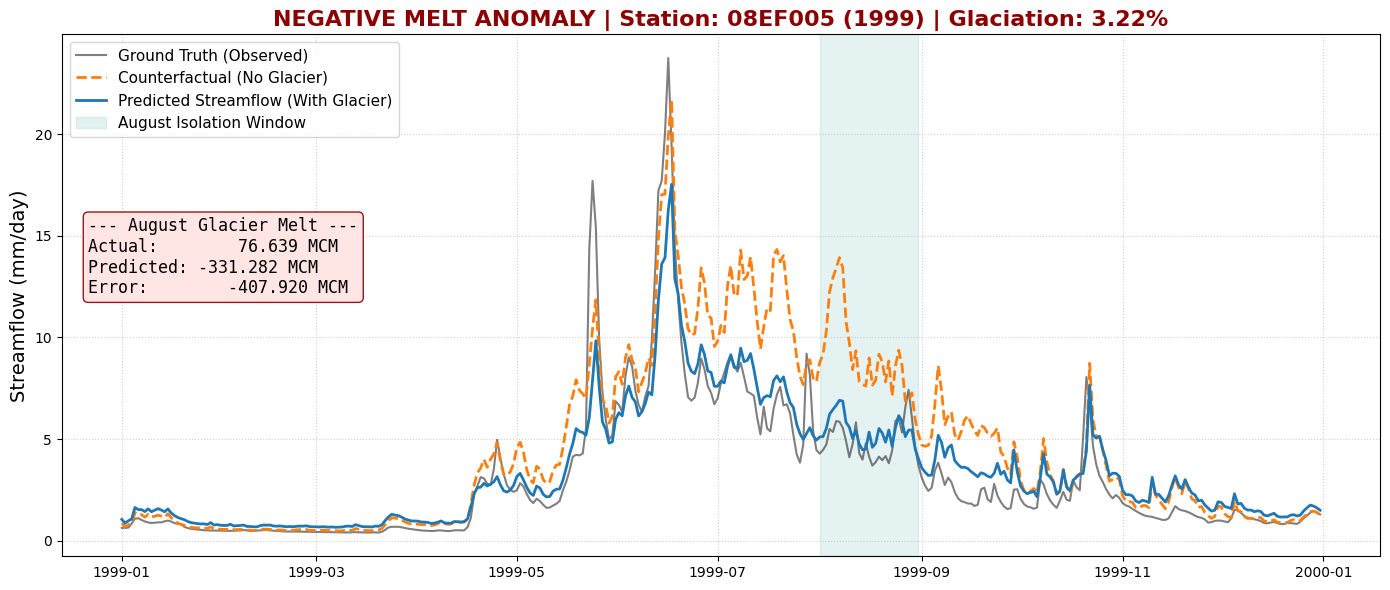

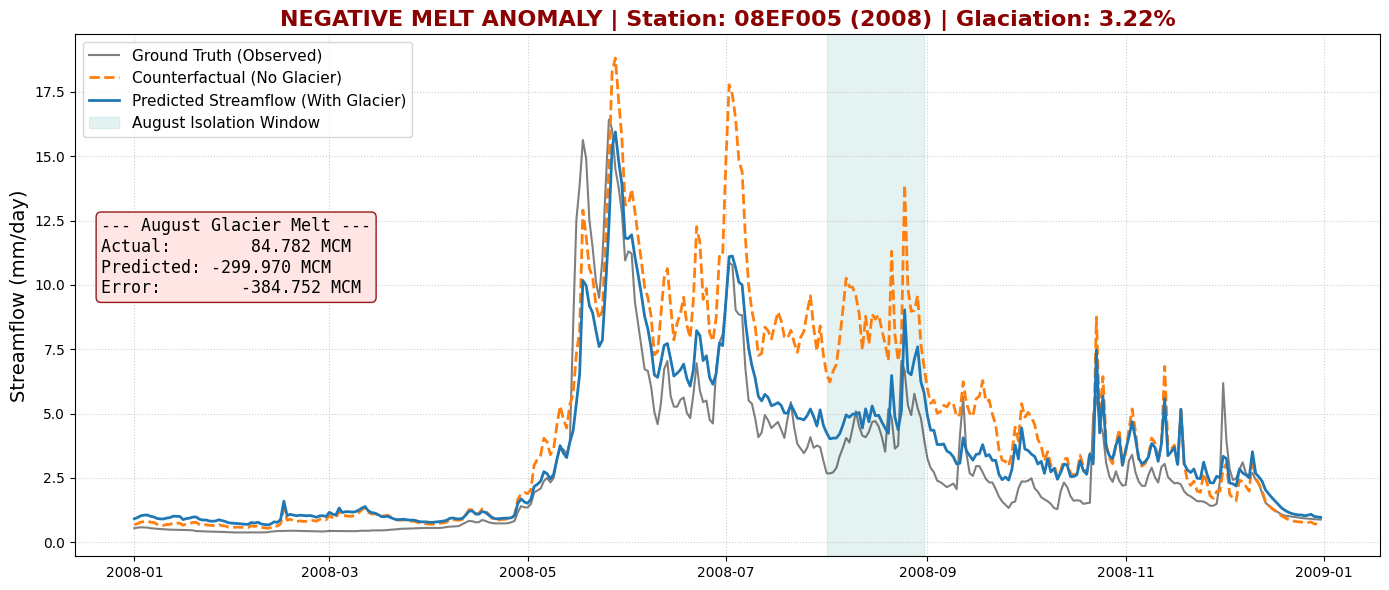

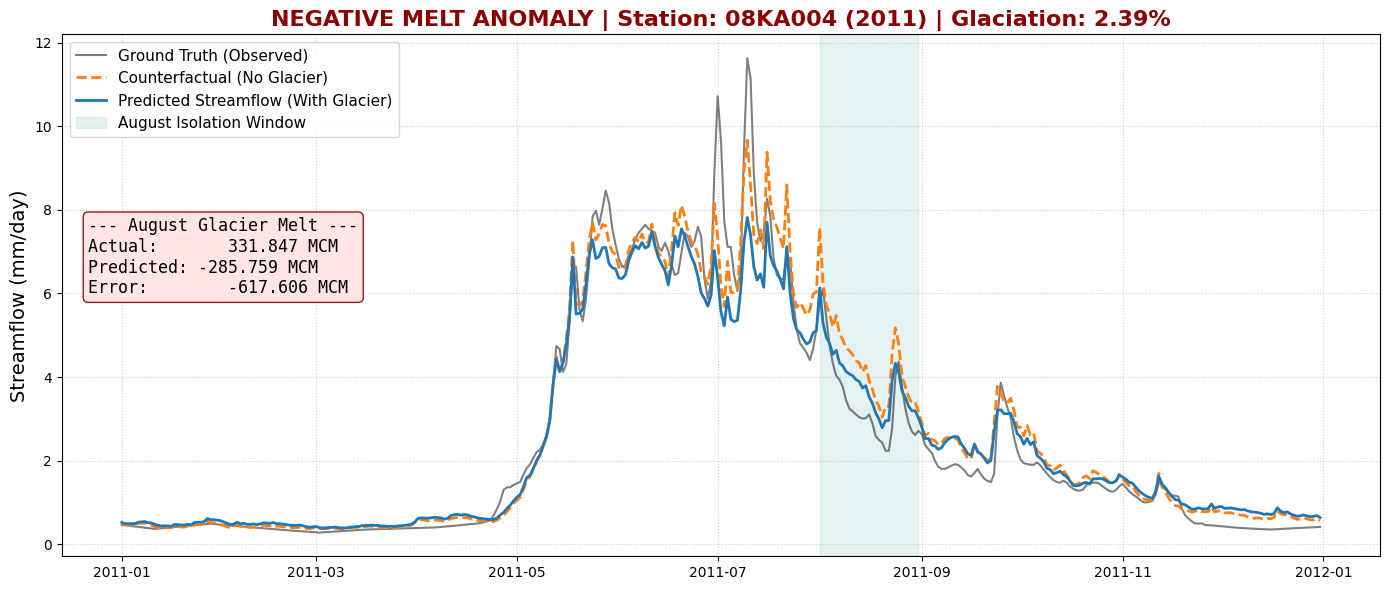

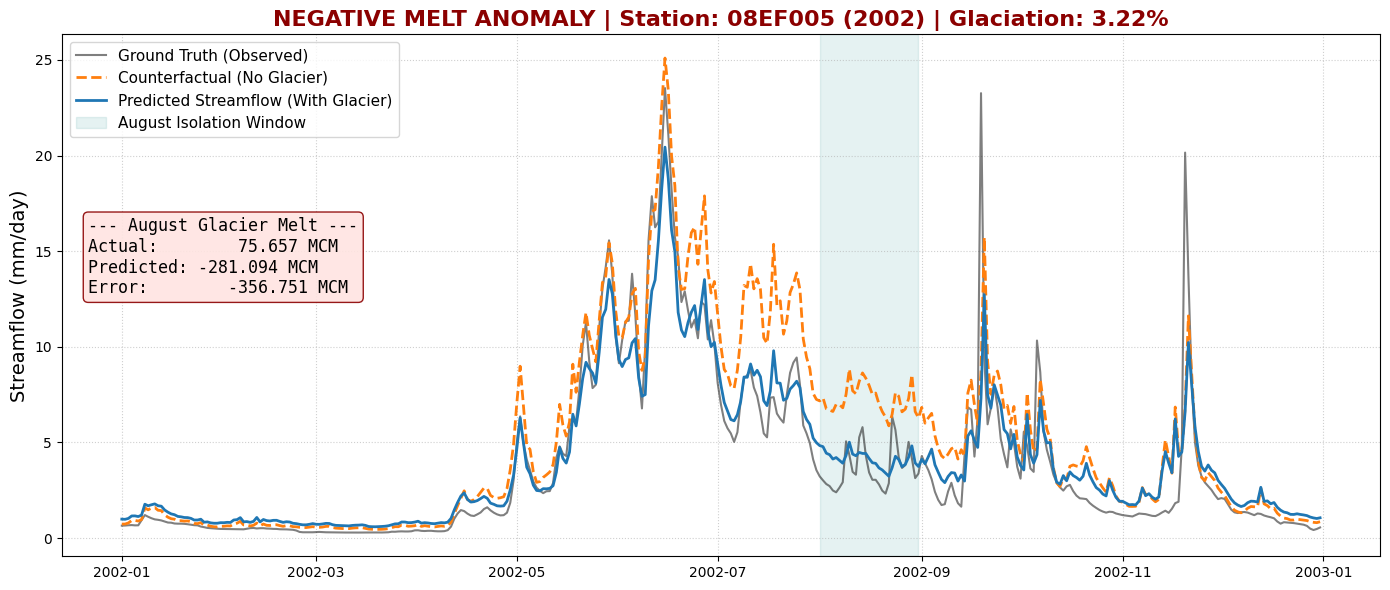

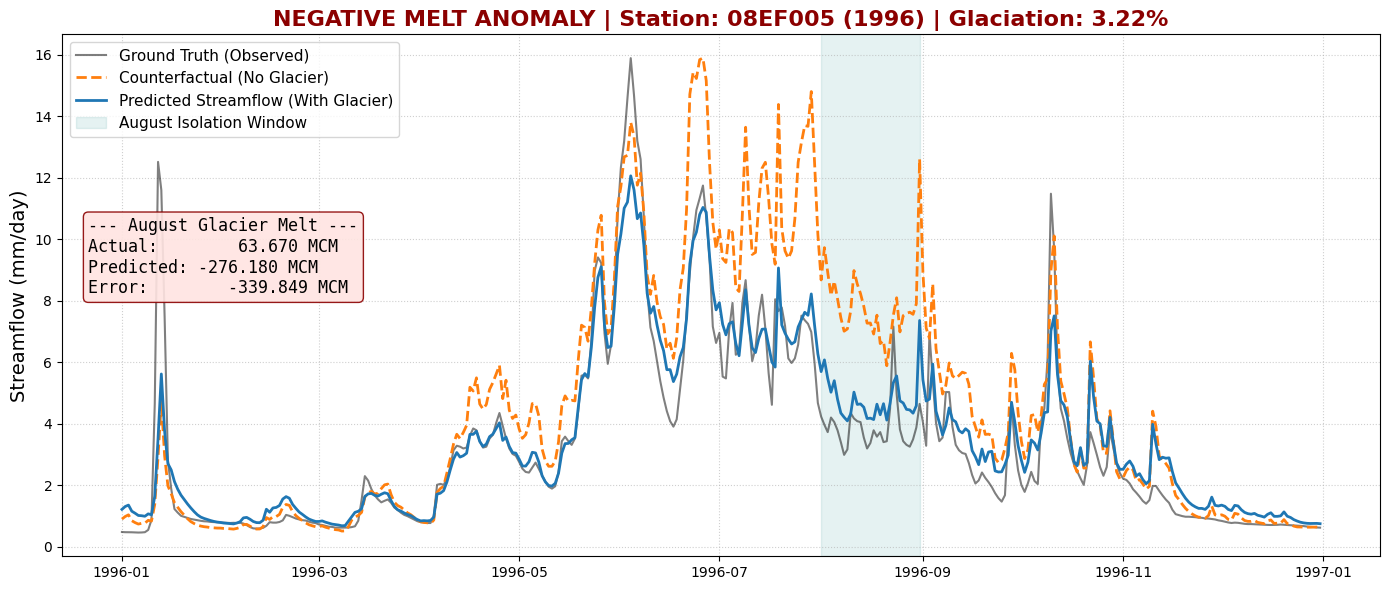

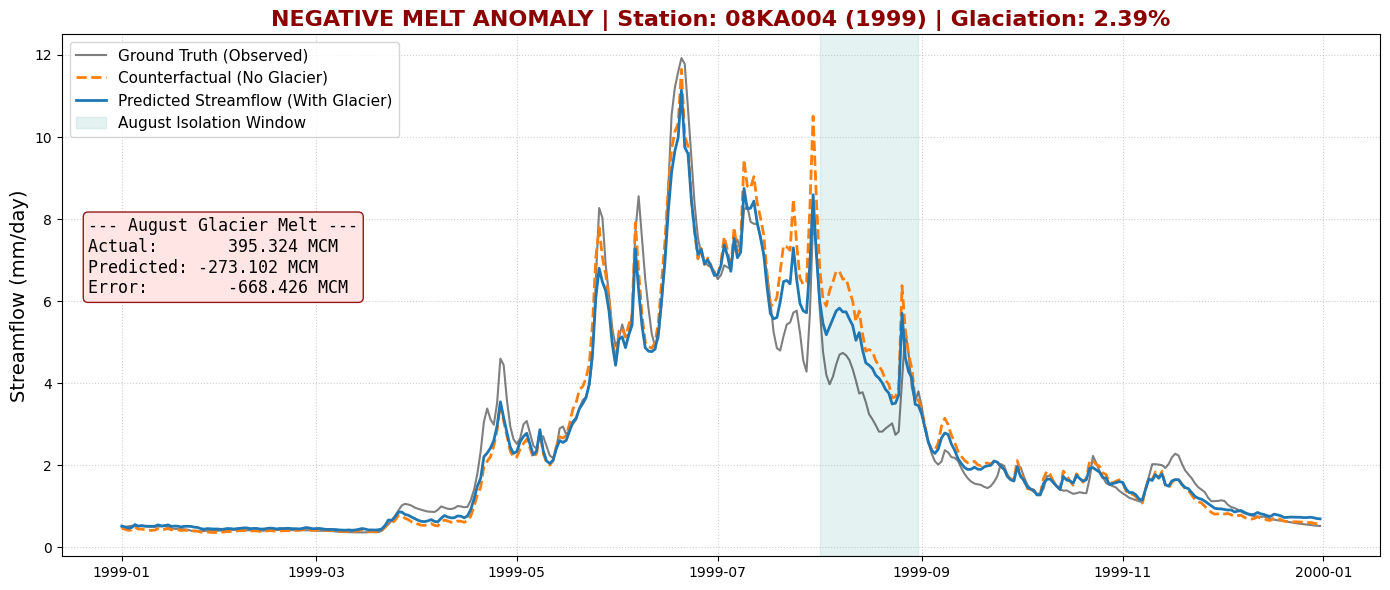

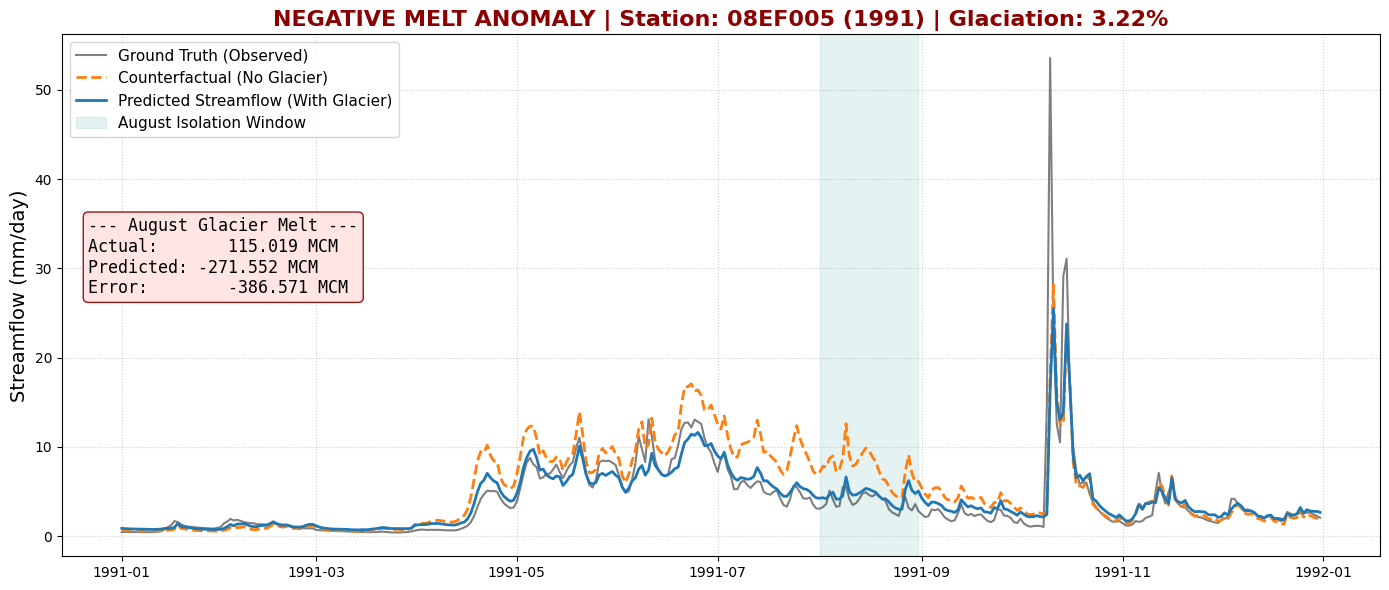

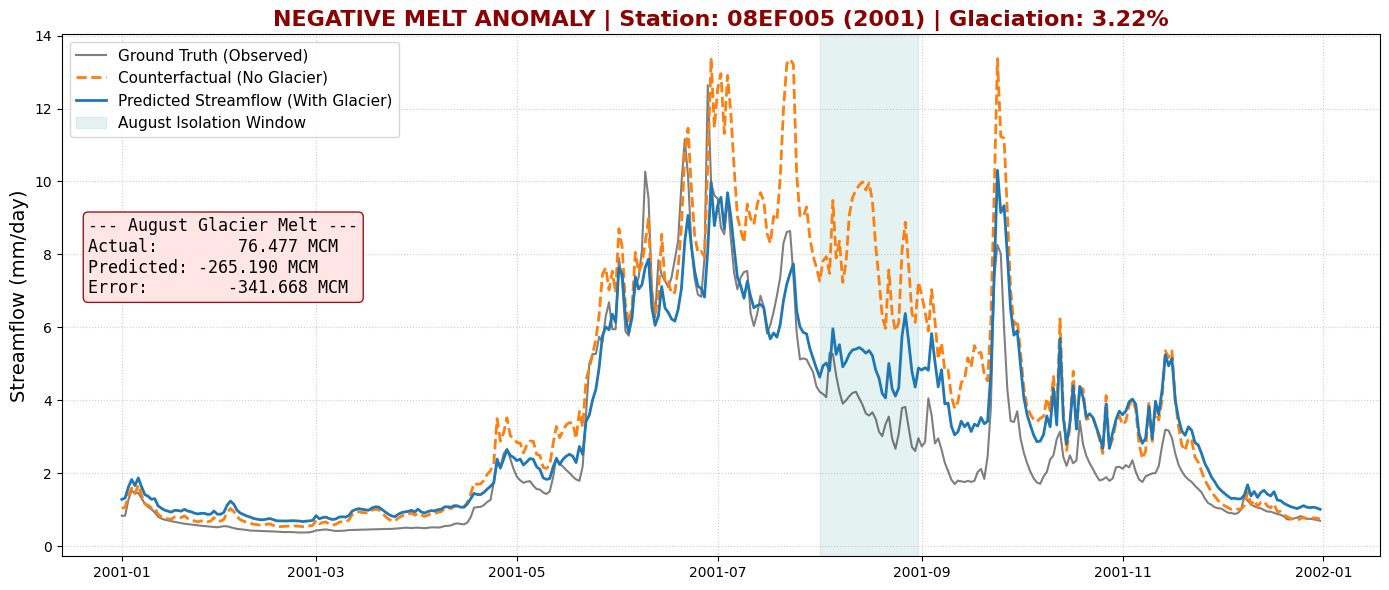

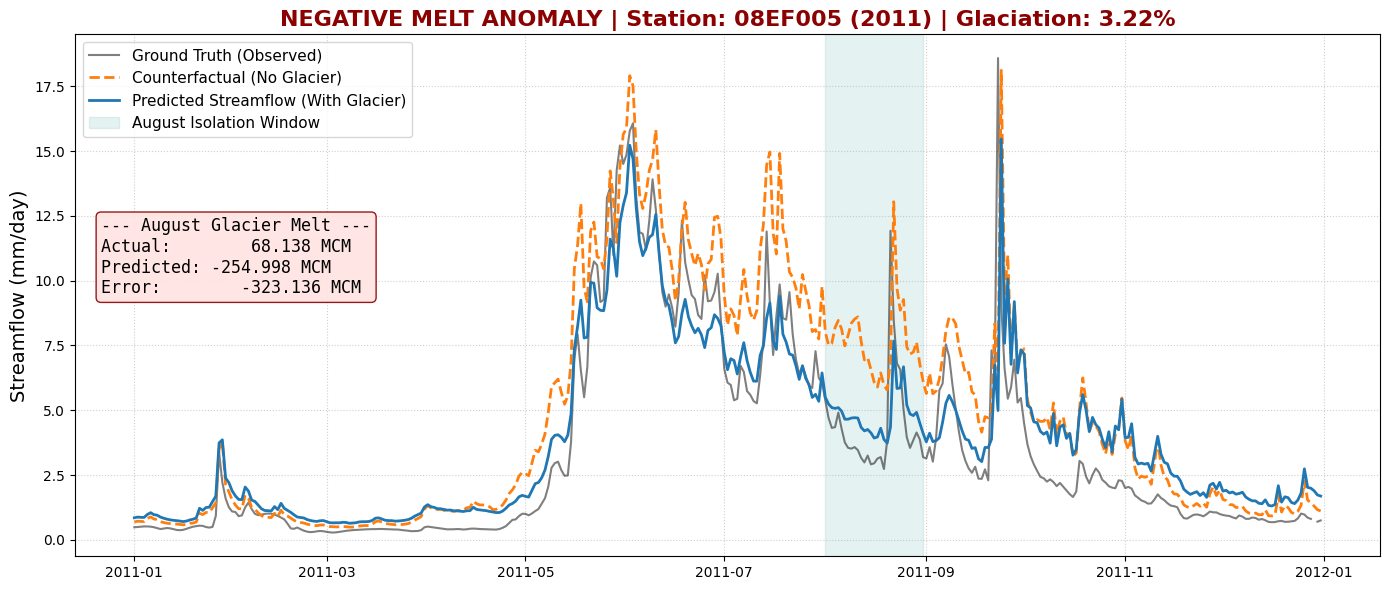

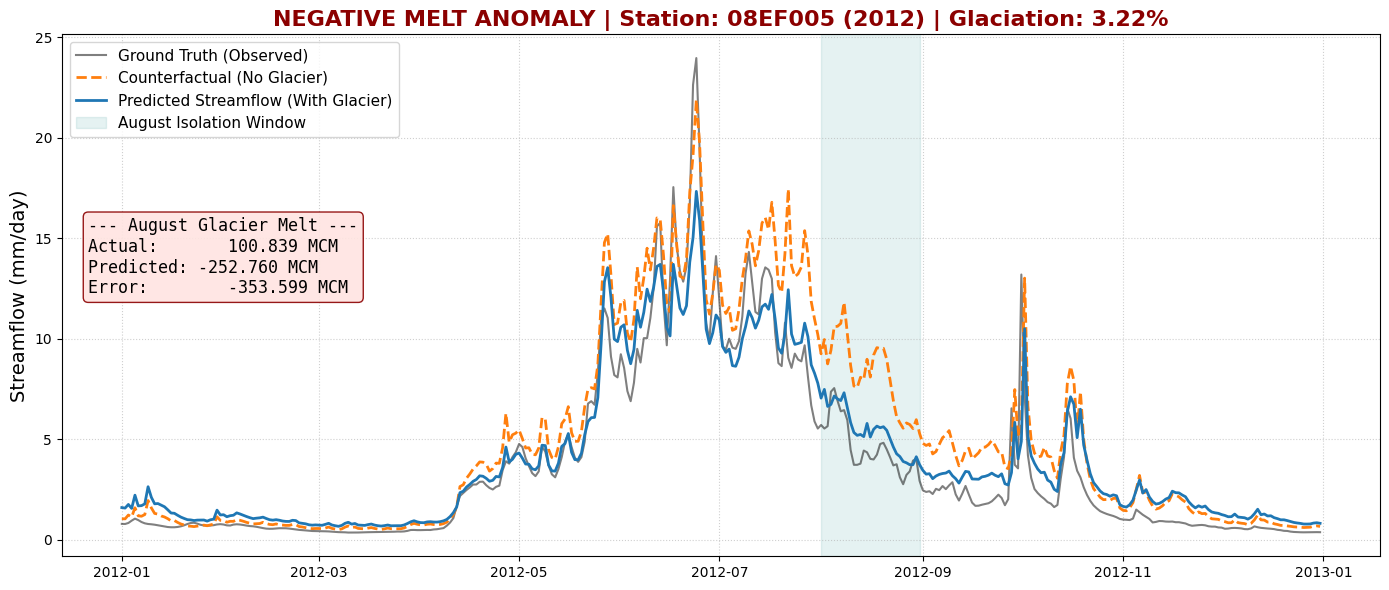

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Load Setup & Identify Glaciated Stations
# =========================================================
print("Loading static attributes and mass balance...")
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
df_mb = -pd.read_csv(PROCESSED_DATA_DIR / "glacier_volume_change.csv", index_col=0, parse_dates=True) 

# Identify glaciated stations
glaciated_stations = df_attr[df_attr['glacier_pct'] > 0].index

# Load one template to get the common index and columns for the full dataset
template = pd.read_csv(OUTPUT_DATA_DIR / "phase_split" / "phase-split_preds_member_0.csv", index_col=0, parse_dates=True)
common_stations = glaciated_stations.intersection(template.columns).intersection(df_mb.columns)
full_dates = template.index

df_mb_full = df_mb[common_stations].copy()
basin_areas = df_attr.loc[common_stations, 'basin_area_km2']

# =========================================================
# 2. Calculate Full Ensemble Means
# =========================================================
print("Calculating ensemble means over the entire dataset (this may take a moment)...")
# ensemble_dir = OUTPUT_DATA_DIR / "phase_split"
ensemble_dir = OUTPUT_DATA_DIR / "topographic"

# Initialize empty dataframes to accumulate the sums
df_pred_sum = pd.DataFrame(0.0, index=full_dates, columns=common_stations)
df_noglac_sum = pd.DataFrame(0.0, index=full_dates, columns=common_stations)

for i in range(10):
    # pred = pd.read_csv(ensemble_dir / f"phase-split_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    # noglac = pd.read_csv(ensemble_dir / f"phase-split_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    pred = pd.read_csv(ensemble_dir / f"topographic_preds_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    noglac = pd.read_csv(ensemble_dir / f"topographic_preds_noglacier_member_{i}.csv", index_col=0, parse_dates=True)[common_stations]
    
    df_pred_sum += pred
    df_noglac_sum += noglac

df_pred_mean = df_pred_sum / 10
df_noglac_mean = df_noglac_sum / 10

# Load Ground Truth and convert to mm/day
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_obs_full = df_obs.loc[df_pred_mean.index.intersection(df_obs.index), common_stations].copy()

for stat in common_stations:
    df_obs_full[stat] = df_obs_full[stat] * (86.4 / basin_areas[stat])

# =========================================================
# 3. Scan for Negative Melt Anomalies (FIXED INDEXING)
# =========================================================
print("Scanning for negative predicted glacier melt anomalies...")

# Calculate daily difference
df_diff_mm = df_pred_mean - df_noglac_mean

# Isolate August and calculate monthly sum (mm/month)
df_diff_aug_mm = df_diff_mm[df_diff_mm.index.month == 8].groupby(df_diff_mm[df_diff_mm.index.month == 8].index.year).sum()

# Convert predicted depth to volume (MCM)
df_pred_mcm_yearly = df_diff_aug_mm * basin_areas * 0.001

# Force the index name to be 'Year' so the melt function works perfectly
df_pred_mcm_yearly.index.name = 'Year'

# Melt dataframe into a long format: [Year, Station, Predicted_MCM]
df_long = df_pred_mcm_yearly.reset_index().melt(id_vars='Year', var_name='Station', value_name='Predicted_MCM')

anomalies = df_long[df_long['Predicted_MCM'] < 0].sort_values(by='Predicted_MCM')

print(f"\n[!] Found {len(anomalies)} occurrences of negative predicted glacier melt.")

# =========================================================
# 4. Plot Anomalies
# =========================================================
MAX_PLOTS = 10  # CHANGE THIS to view more or fewer plots

if len(anomalies) > 0:
    plots_to_show = min(len(anomalies), MAX_PLOTS)
    print(f"Generating plots for the Top {plots_to_show} most extreme negative occurrences...\n")
    
    for idx, row in anomalies.head(plots_to_show).iterrows():
        target_year = int(row['Year'])
        target_station = row['Station']
        pred_melt_mcm = row['Predicted_MCM']
        
        # Slice the timeseries for the selected year
        obs_year = df_obs_full.loc[str(target_year), target_station]
        pred_year = df_pred_mean.loc[str(target_year), target_station]
        noglac_year = df_noglac_mean.loc[str(target_year), target_station]
        
        # Get actual melt (safe fetch in case of missing data)
        try:
            act_melt_mcm = df_mb_full.loc[f"{target_year}-08", target_station].sum()
        except KeyError:
            act_melt_mcm = np.nan
            
        # --- Plotting ---
        fig, ax = plt.subplots(figsize=(14, 6))

        ax.plot(obs_year.index, obs_year.values, color='black', alpha=0.5, label='Ground Truth (Observed)', linewidth=1.5)
        ax.plot(noglac_year.index, noglac_year.values, color='tab:orange', linestyle='--', label='Counterfactual (No Glacier)', linewidth=2)
        ax.plot(pred_year.index, pred_year.values, color='tab:blue', label='Predicted Streamflow (With Glacier)', linewidth=2)

        # Highlight August
        august_start = pd.to_datetime(f"{target_year}-08-01")
        august_end = pd.to_datetime(f"{target_year}-08-31")
        ax.axvspan(august_start, august_end, color='teal', alpha=0.1, label='August Isolation Window')

        # Formatting
        glac_pct = df_attr.loc[target_station, 'glacier_pct']
        ax.set_title(f"NEGATIVE MELT ANOMALY | Station: {target_station} ({target_year}) | Glaciation: {glac_pct:.2f}%", fontsize=16, fontweight='bold', color='darkred')
        ax.set_ylabel("Streamflow (mm/day)", fontsize=14)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper left', fontsize=11)

        # Text Box with August Volumes
        text_str = (
            f"--- August Glacier Melt ---\n"
            f"Actual:       {act_melt_mcm:>7.3f} MCM\n"
            f"Predicted: {pred_melt_mcm:>7.3f} MCM\n"
            f"Error:        {(pred_melt_mcm - act_melt_mcm):>7.3f} MCM"
        )
        props = dict(boxstyle='round', facecolor='mistyrose', alpha=0.9, edgecolor='darkred')
        ax.text(0.02, 0.65, text_str, transform=ax.transAxes, fontsize=12, family='monospace',
                verticalalignment='top', bbox=props)

        plt.tight_layout()
        plt.show()
else:
    print("No negative predicted melt occurrences found in the dataset!")